# Experimentos do Trabalho 1 - Reconhecimento de Padrões
## Aluno: Apolinário

### 1. Imports e Carregamento do Dataset

In [7]:
import pandas as pd
import numpy as np
import time
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from classificao_padroes.models import KNN, MDC, MAXCO
from ucimlrepo import fetch_ucirepo

In [8]:
# Carregar o dataset
vertebral_column = fetch_ucirepo(id=212)
X = vertebral_column.data.features.to_numpy()
y_raw = vertebral_column.data.targets.to_numpy().ravel()

# Codificar as labels para valores numéricos
le = LabelEncoder()
y = le.fit_transform(y_raw)

print("Shape of X:", X.shape)
print("Shape of y:", y.shape)
print("Classes:", le.classes_)
print("Encoded Classes:", np.unique(y))

Shape of X: (310, 6)
Shape of y: (310,)
Classes: ['Hernia' 'Normal' 'Spondylolisthesis']
Encoded Classes: [0 1 2]


### 2. Definição e Execução dos Experimentos

In [9]:
def run_experiments(X, y, test_size, n_runs=100):
    le = LabelEncoder()
    y = le.fit_transform(y.ravel())
    
    minkowski_orders = [0.5, 2/3, 1, 3/2, 2, 5/2]
    classifiers = {f'KNN (m={m:.2f})': KNN for m in minkowski_orders}
    classifiers['MDC'] = MDC
    classifiers['MDC Robusto'] = (MDC, {'robustVersion': True})
    classifiers['MAXCO'] = MAXCO

    results = {name: [] for name in classifiers.keys()}

    for i in range(n_runs):
        X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=test_size, random_state=i, stratify=y)

        for name, clf_class in classifiers.items():
            params = {}
            if isinstance(clf_class, tuple):
                clf_class, params = clf_class

            # Treinamento
            start_train_time = time.time()
            if 'KNN' in name:
                m = float(name.split('=')[1][:-1])
                model = clf_class(X=X_train, Y=y_train, k=1, minkowskiOrder=m)
            elif 'MDC' in name:
                model = clf_class(X=X_train, Y=y_train, **params)
                model.train()
            elif 'MAXCO' in name:
                model = clf_class(X=X_train, Y=y_train)
                model.train()
            train_time = time.time() - start_train_time

            # Teste
            start_test_time = time.time()
            y_pred = model.predict(X_test)
            test_time = time.time() - start_test_time

            # Salvar resultados
            accuracy = accuracy_score(y_test, y_pred)
            results[name].append({
                'run': i,
                'accuracy': accuracy,
                'train_time': train_time,
                'test_time': test_time,
                'y_test': y_test,
                'y_pred': y_pred
            })
    return results, le

### 3. Análise dos Resultados

In [10]:
def analyze_results(results, le):
    summary_data = []
    for name, runs in results.items():
        accuracies = [r['accuracy'] for r in runs]
        train_times = [r['train_time'] for r in runs]
        test_times = [r['test_time'] for r in runs]

        # OBS 1 & 2
        summary = {
            'Classifier': name,
            'Mean Accuracy': np.mean(accuracies),
            'Std Accuracy': np.std(accuracies),
            'Min Accuracy': np.min(accuracies),
            'Max Accuracy': np.max(accuracies),
            'Median Accuracy': np.median(accuracies),
            'Mean Train Time (s)': np.mean(train_times),
            'Mean Test Time (s)': np.mean(test_times)
        }
        summary_data.append(summary)

    summary_df = pd.DataFrame(summary_data).sort_values(by='Mean Accuracy', ascending=False)
    display(summary_df)

    # OBS 2: Matrizes de confusão para melhor e pior rodada
    for name, runs in results.items():
        accuracies = [r['accuracy'] for r in runs]
        best_run_idx = np.argmax(accuracies)
        worst_run_idx = np.argmin(accuracies)
        best_run = runs[best_run_idx]
        worst_run = runs[worst_run_idx]

        print(f'--- {name} ---')
        print(f'Best Run (#{best_run["run"]}) Accuracy: {best_run["accuracy"]:.4f}')
        print(f"Worst Run (#{worst_run['run']}) Accuracy: {worst_run['accuracy']:.4f}")

        fig, axes = plt.subplots(1, 2, figsize=(15, 5))
        cm_best = confusion_matrix(best_run['y_test'], best_run['y_pred'])
        sns.heatmap(cm_best, annot=True, fmt='d', cmap='Blues', xticklabels=le.classes_, yticklabels=le.classes_, ax=axes[0])
        axes[0].set_title(f'Best Run Confusion Matrix')
        axes[0].set_xlabel('Predicted')
        axes[0].set_ylabel('True')

        cm_worst = confusion_matrix(worst_run['y_test'], worst_run['y_pred'])
        sns.heatmap(cm_worst, annot=True, fmt='d', cmap='Reds', xticklabels=le.classes_, yticklabels=le.classes_, ax=axes[1])
        axes[1].set_title(f'Worst Run Confusion Matrix')
        axes[1].set_xlabel('Predicted')
        axes[1].set_ylabel('True')
        plt.tight_layout()
        plt.show()

        # OBS 4: Estatísticas por classe (para a melhor rodada)
        print(f'Classification Report for Best Run (#{best_run["run"]}):')
        print(classification_report(best_run['y_test'], best_run['y_pred'], target_names=le.classes_))

### 4. Execução Principal e Análise por Split de Teste

   Running Experiments for Train/Test Split: 19/80   


,Classifier,Mean Accuracy,Std Accuracy,Min Accuracy,Max Accuracy,Median Accuracy,Mean Train Time (s),Mean Test Time (s)
4,KNN (m=2.00),0.784516,0.028124,0.685484,0.834677,0.786290,0.000005,0.005571
3,KNN (m=1.50),0.784516,0.029709,0.669355,0.842742,0.790323,0.000005,0.006040
5,KNN (m=2.50),0.783669,0.027309,0.673387,0.834677,0.786290,0.000005,0.005584
2,KNN (m=1.00),0.778710,0.029134,0.693548,0.846774,0.778226,0.000005,0.005338
7,MDC Robusto,0.772944,0.033970,0.673387,0.846774,0.776210,0.000200,0.001577
1,KNN (m=0.67),0.765847,0.027213,0.689516,0.822581,0.768145,0.000007,0.006053
6,MDC,0.760565,0.045114,0.592742,0.846774,0.764113,0.000101,0.001608
0,KNN (m=0.50),0.756815,0.028247,0.677419,0.830645,0.758065,0.000007,0.005729
8,MAXCO,0.713024,0.052021,0.540323,0.802419,0.719758,0.000072,0.009516


--- KNN (m=0.50) ---
Best Run (#98) Accuracy: 0.8306
Worst Run (#77) Accuracy: 0.6774


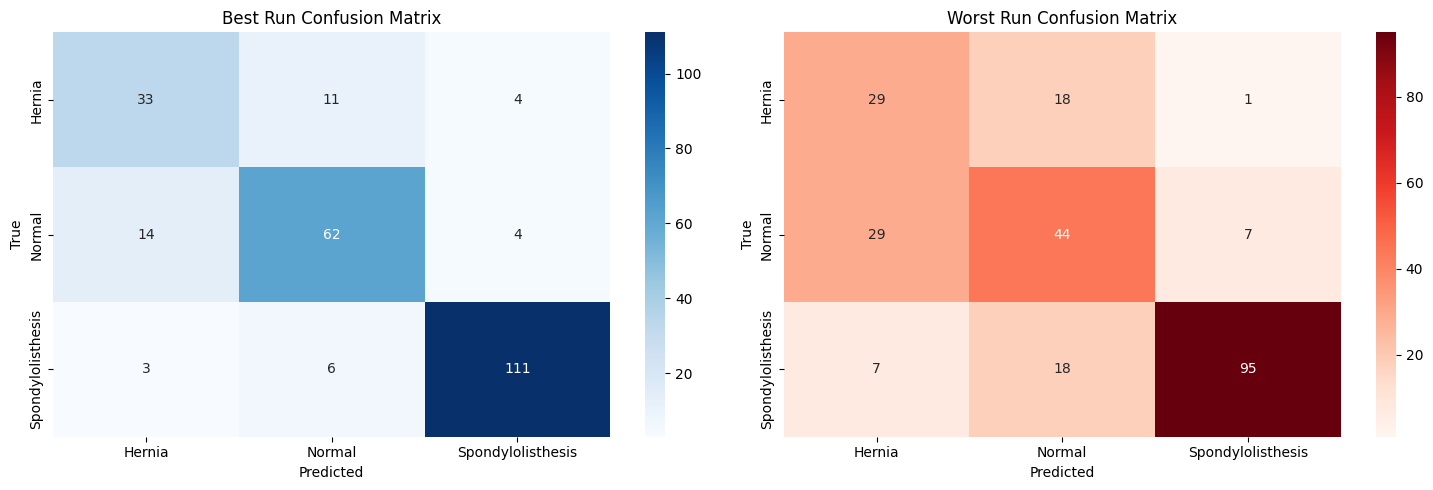

Classification Report for Best Run (#98):
                   precision    recall  f1-score   support

           Hernia       0.66      0.69      0.67        48
           Normal       0.78      0.78      0.78        80
Spondylolisthesis       0.93      0.93      0.93       120

         accuracy                           0.83       248
        macro avg       0.79      0.80      0.79       248
     weighted avg       0.83      0.83      0.83       248

--- KNN (m=0.67) ---
Best Run (#0) Accuracy: 0.8226
Worst Run (#77) Accuracy: 0.6895


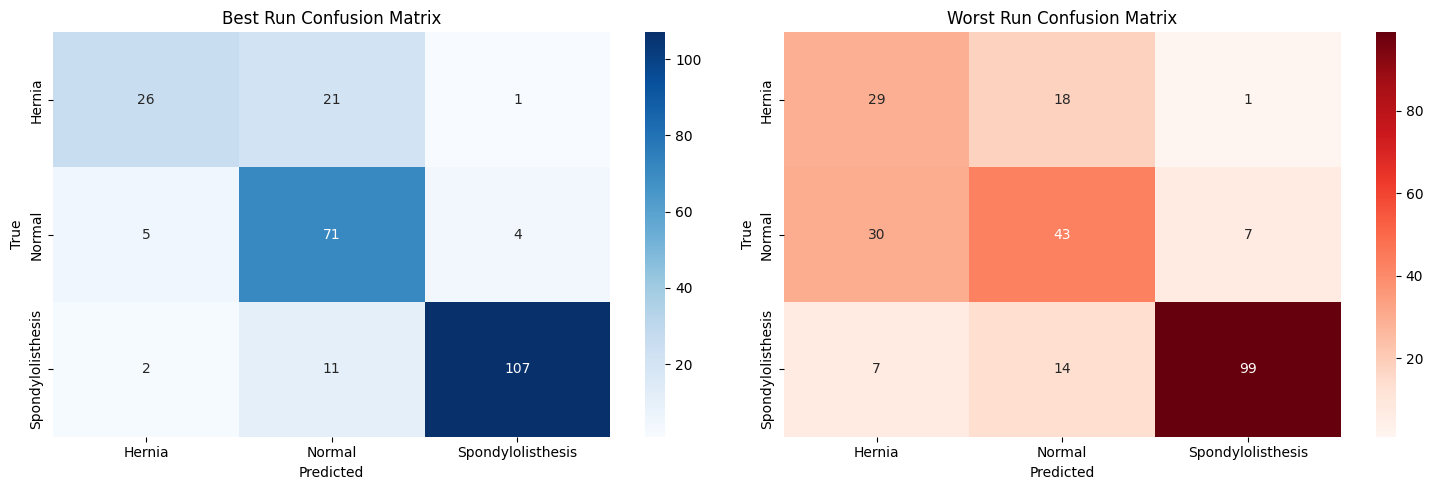

Classification Report for Best Run (#0):
                   precision    recall  f1-score   support

           Hernia       0.79      0.54      0.64        48
           Normal       0.69      0.89      0.78        80
Spondylolisthesis       0.96      0.89      0.92       120

         accuracy                           0.82       248
        macro avg       0.81      0.77      0.78       248
     weighted avg       0.84      0.82      0.82       248

--- KNN (m=1.00) ---
Best Run (#98) Accuracy: 0.8468
Worst Run (#22) Accuracy: 0.6935


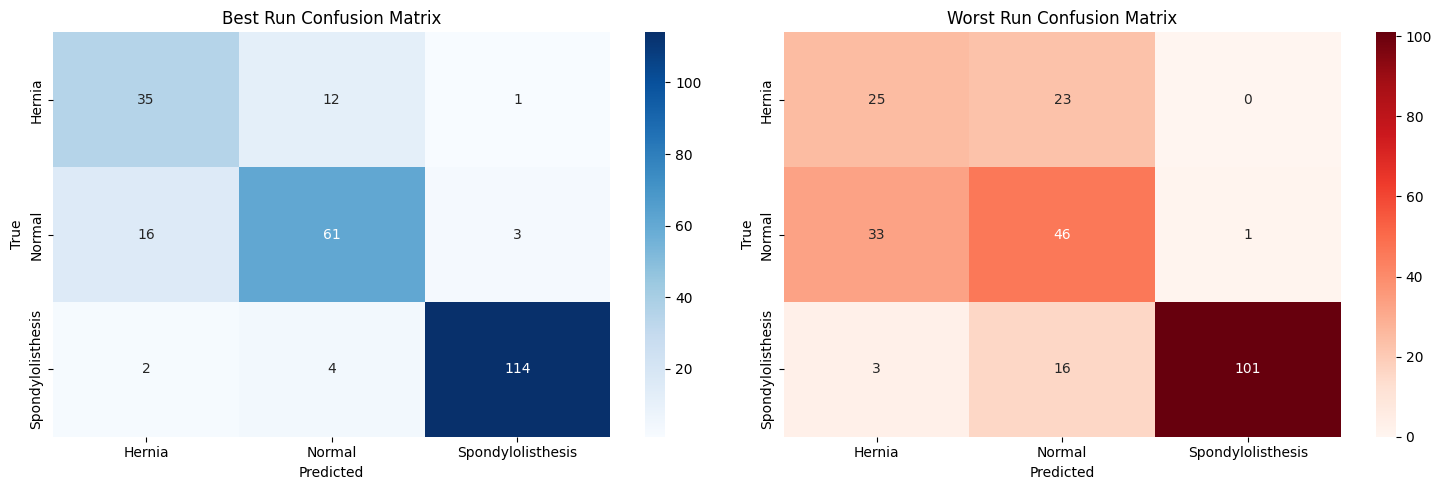

Classification Report for Best Run (#98):
                   precision    recall  f1-score   support

           Hernia       0.66      0.73      0.69        48
           Normal       0.79      0.76      0.78        80
Spondylolisthesis       0.97      0.95      0.96       120

         accuracy                           0.85       248
        macro avg       0.81      0.81      0.81       248
     weighted avg       0.85      0.85      0.85       248

--- KNN (m=1.50) ---
Best Run (#1) Accuracy: 0.8427
Worst Run (#31) Accuracy: 0.6694


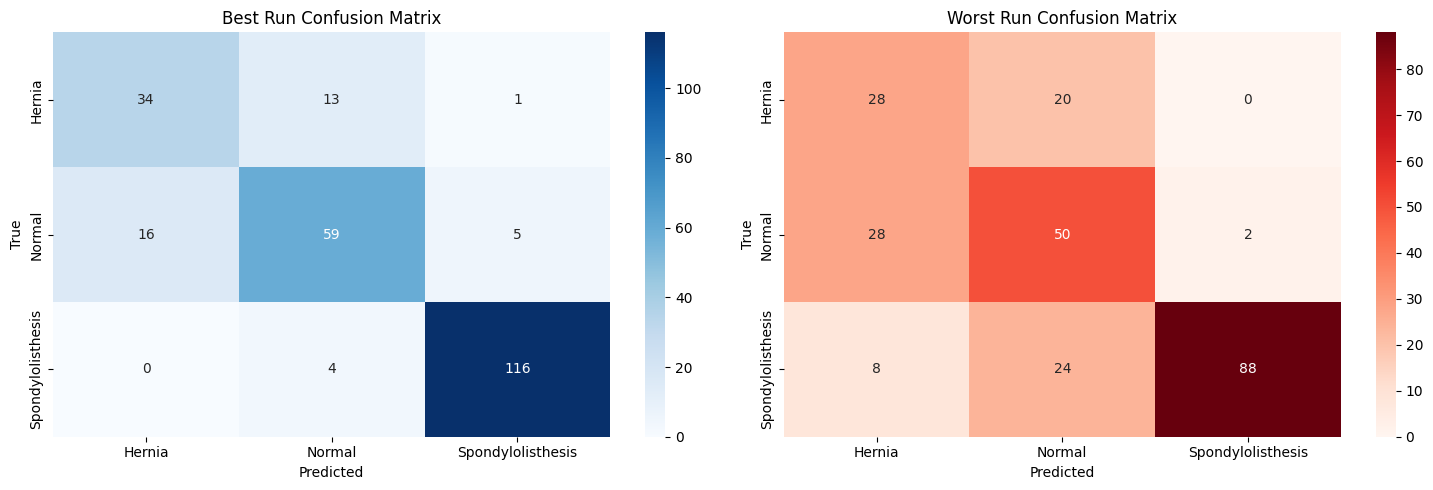

Classification Report for Best Run (#1):
                   precision    recall  f1-score   support

           Hernia       0.68      0.71      0.69        48
           Normal       0.78      0.74      0.76        80
Spondylolisthesis       0.95      0.97      0.96       120

         accuracy                           0.84       248
        macro avg       0.80      0.80      0.80       248
     weighted avg       0.84      0.84      0.84       248

--- KNN (m=2.00) ---
Best Run (#87) Accuracy: 0.8347
Worst Run (#31) Accuracy: 0.6855


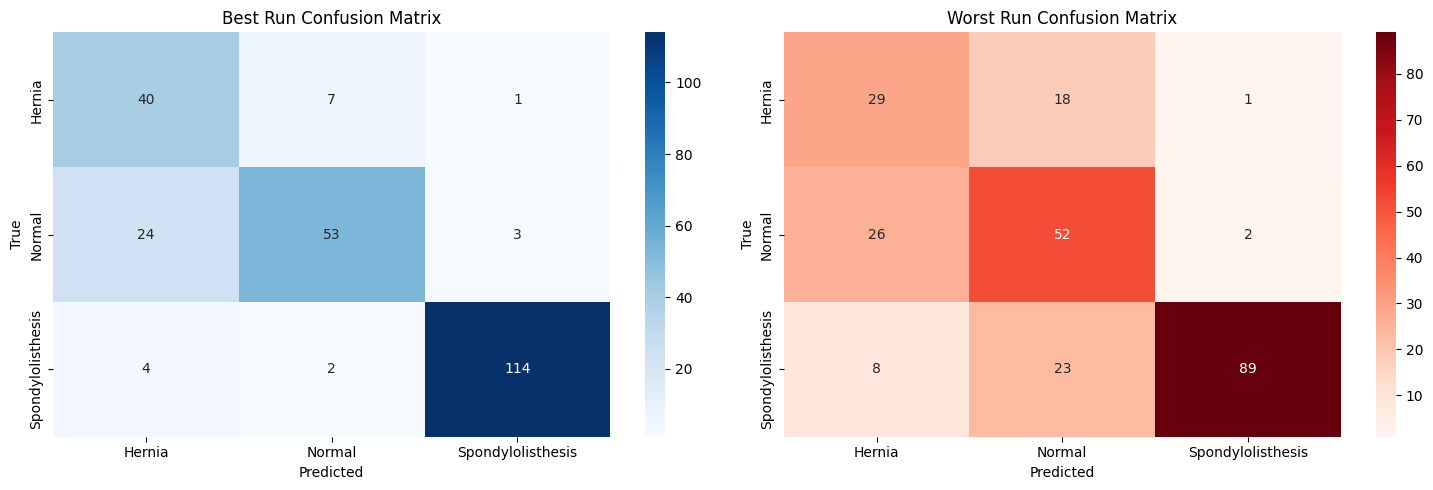

Classification Report for Best Run (#87):
                   precision    recall  f1-score   support

           Hernia       0.59      0.83      0.69        48
           Normal       0.85      0.66      0.75        80
Spondylolisthesis       0.97      0.95      0.96       120

         accuracy                           0.83       248
        macro avg       0.80      0.82      0.80       248
     weighted avg       0.86      0.83      0.84       248

--- KNN (m=2.50) ---
Best Run (#6) Accuracy: 0.8347
Worst Run (#31) Accuracy: 0.6734


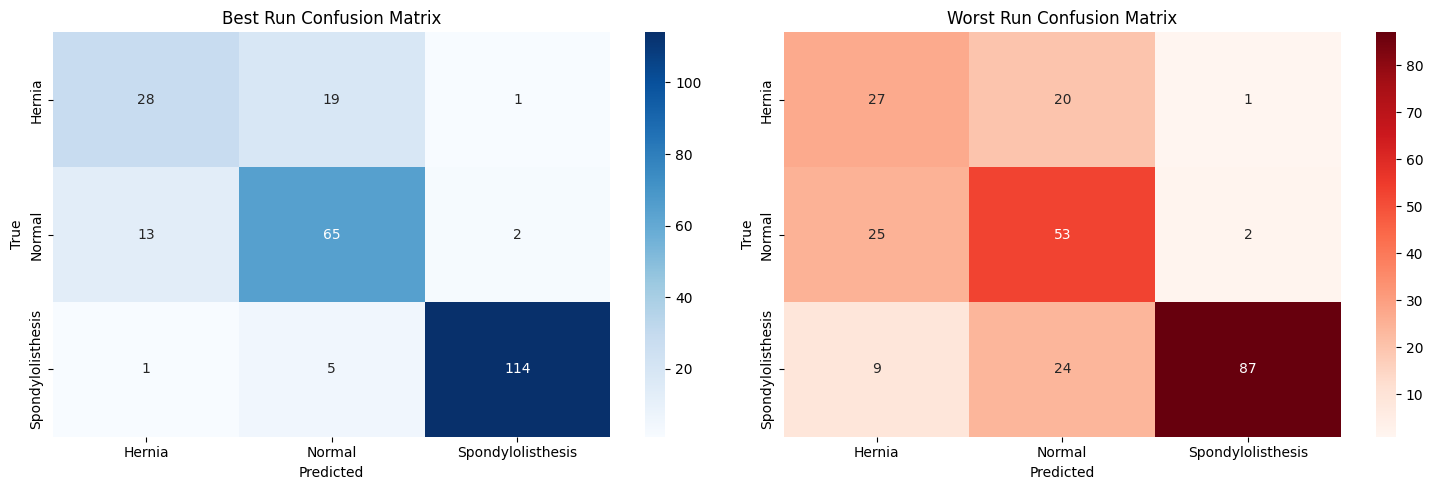

Classification Report for Best Run (#6):
                   precision    recall  f1-score   support

           Hernia       0.67      0.58      0.62        48
           Normal       0.73      0.81      0.77        80
Spondylolisthesis       0.97      0.95      0.96       120

         accuracy                           0.83       248
        macro avg       0.79      0.78      0.78       248
     weighted avg       0.84      0.83      0.83       248

--- MDC ---
Best Run (#6) Accuracy: 0.8468
Worst Run (#31) Accuracy: 0.5927


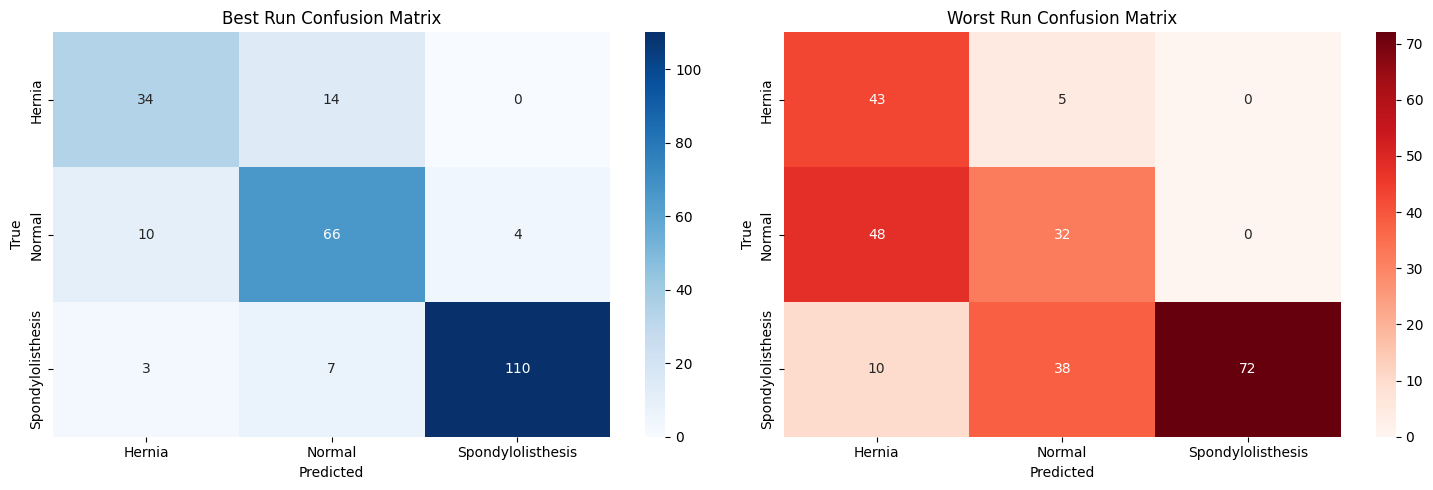

Classification Report for Best Run (#6):
                   precision    recall  f1-score   support

           Hernia       0.72      0.71      0.72        48
           Normal       0.76      0.82      0.79        80
Spondylolisthesis       0.96      0.92      0.94       120

         accuracy                           0.85       248
        macro avg       0.82      0.82      0.82       248
     weighted avg       0.85      0.85      0.85       248

--- MDC Robusto ---
Best Run (#83) Accuracy: 0.8468
Worst Run (#31) Accuracy: 0.6734


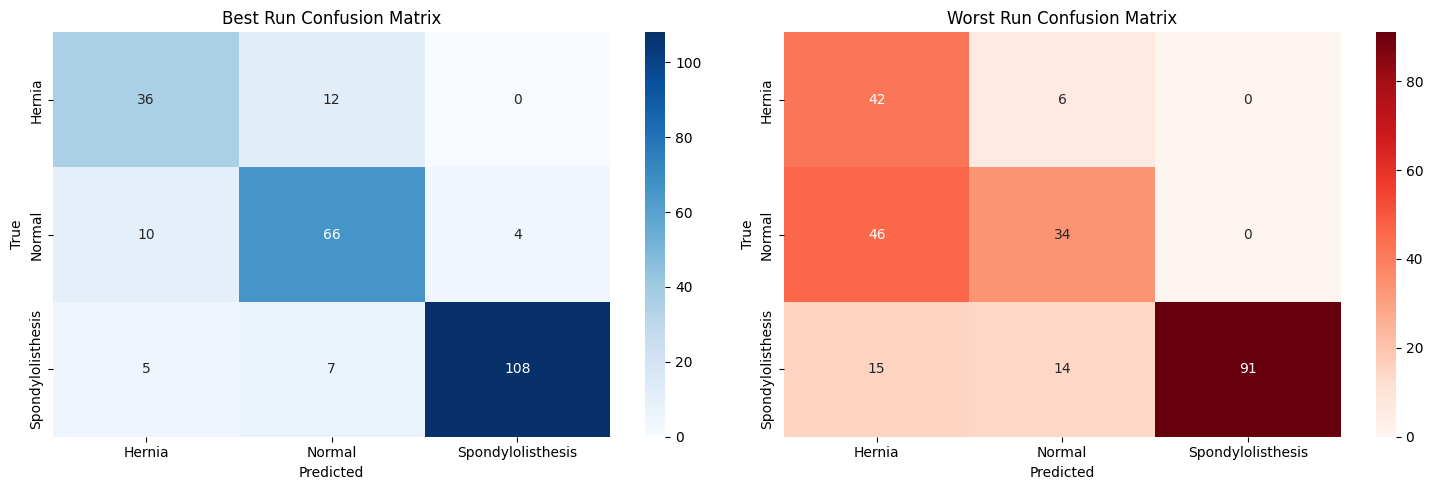

Classification Report for Best Run (#83):
                   precision    recall  f1-score   support

           Hernia       0.71      0.75      0.73        48
           Normal       0.78      0.82      0.80        80
Spondylolisthesis       0.96      0.90      0.93       120

         accuracy                           0.85       248
        macro avg       0.82      0.83      0.82       248
     weighted avg       0.85      0.85      0.85       248

--- MAXCO ---
Best Run (#84) Accuracy: 0.8024
Worst Run (#76) Accuracy: 0.5403


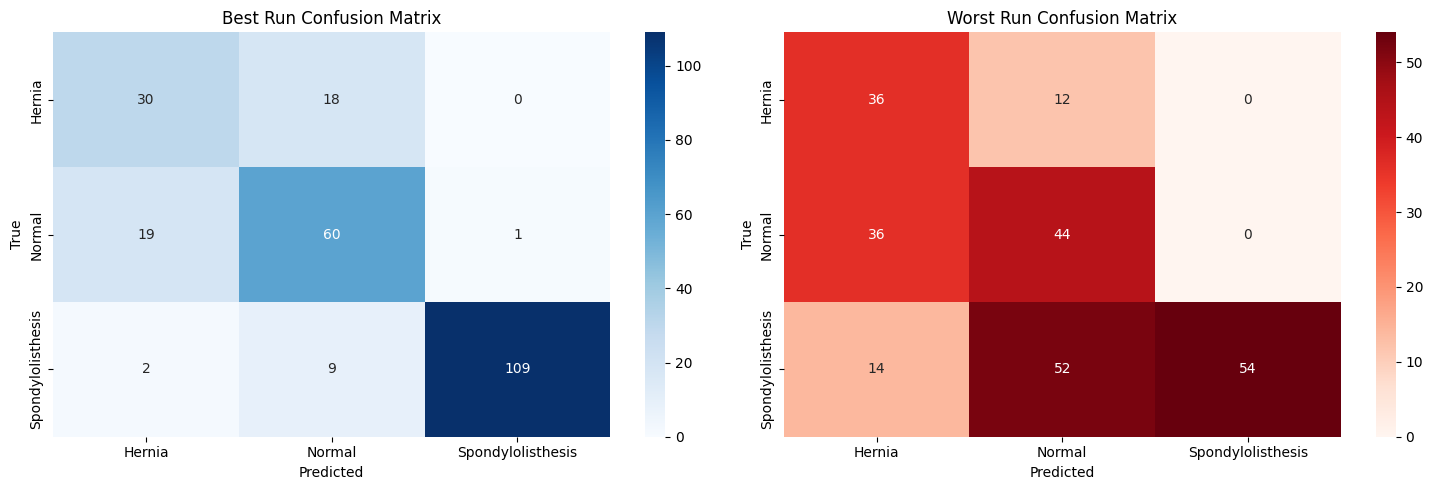

Classification Report for Best Run (#84):
                   precision    recall  f1-score   support

           Hernia       0.59      0.62      0.61        48
           Normal       0.69      0.75      0.72        80
Spondylolisthesis       0.99      0.91      0.95       120

         accuracy                           0.80       248
        macro avg       0.76      0.76      0.76       248
     weighted avg       0.82      0.80      0.81       248

   Running Experiments for Train/Test Split: 30/70   


,Classifier,Mean Accuracy,Std Accuracy,Min Accuracy,Max Accuracy,Median Accuracy,Mean Train Time (s),Mean Test Time (s)
4,KNN (m=2.00),0.794931,0.028351,0.714286,0.857143,0.797235,0.000006,0.005835
5,KNN (m=2.50),0.793641,0.027523,0.695853,0.852535,0.797235,0.000006,0.006192
3,KNN (m=1.50),0.792488,0.030010,0.691244,0.861751,0.792627,0.000006,0.006147
2,KNN (m=1.00),0.786498,0.027811,0.700461,0.847926,0.790323,0.000006,0.005950
7,MDC Robusto,0.777327,0.029700,0.649770,0.838710,0.778802,0.000192,0.001368
1,KNN (m=0.67),0.771935,0.024012,0.691244,0.829493,0.774194,0.000007,0.006146
6,MDC,0.765115,0.034837,0.663594,0.843318,0.769585,0.000102,0.001460
0,KNN (m=0.50),0.760276,0.024393,0.705069,0.820276,0.764977,0.000008,0.005749
8,MAXCO,0.719263,0.043843,0.599078,0.829493,0.728111,0.000073,0.009115


--- KNN (m=0.50) ---
Best Run (#98) Accuracy: 0.8203
Worst Run (#34) Accuracy: 0.7051


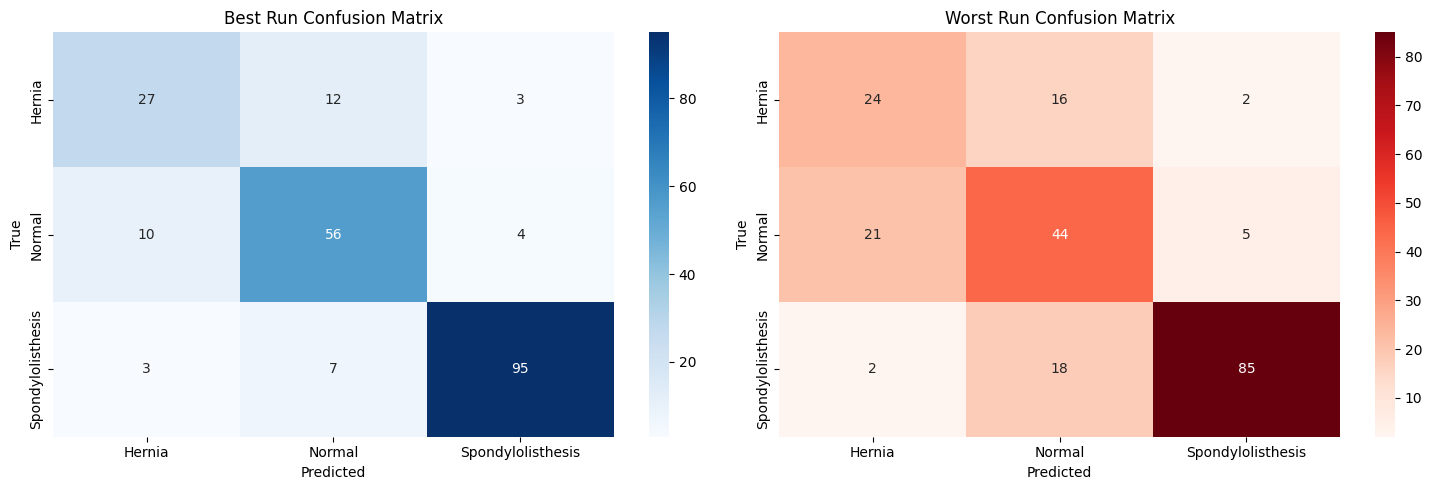

Classification Report for Best Run (#98):
                   precision    recall  f1-score   support

           Hernia       0.68      0.64      0.66        42
           Normal       0.75      0.80      0.77        70
Spondylolisthesis       0.93      0.90      0.92       105

         accuracy                           0.82       217
        macro avg       0.78      0.78      0.78       217
     weighted avg       0.82      0.82      0.82       217

--- KNN (m=0.67) ---
Best Run (#65) Accuracy: 0.8295
Worst Run (#49) Accuracy: 0.6912


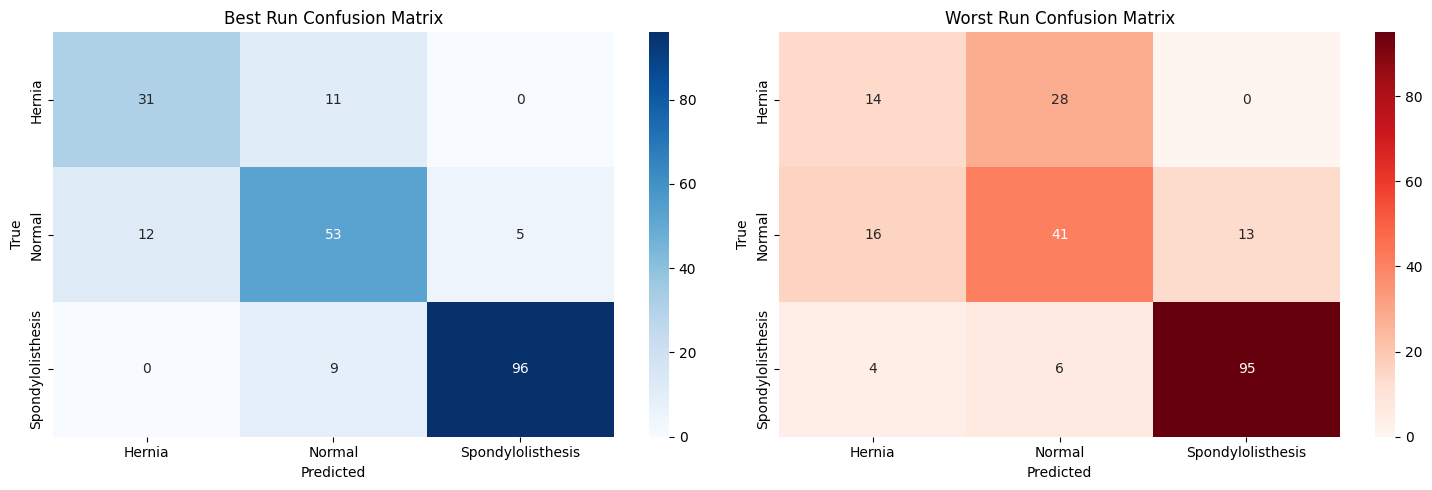

Classification Report for Best Run (#65):
                   precision    recall  f1-score   support

           Hernia       0.72      0.74      0.73        42
           Normal       0.73      0.76      0.74        70
Spondylolisthesis       0.95      0.91      0.93       105

         accuracy                           0.83       217
        macro avg       0.80      0.80      0.80       217
     weighted avg       0.83      0.83      0.83       217

--- KNN (m=1.00) ---
Best Run (#1) Accuracy: 0.8479
Worst Run (#49) Accuracy: 0.7005


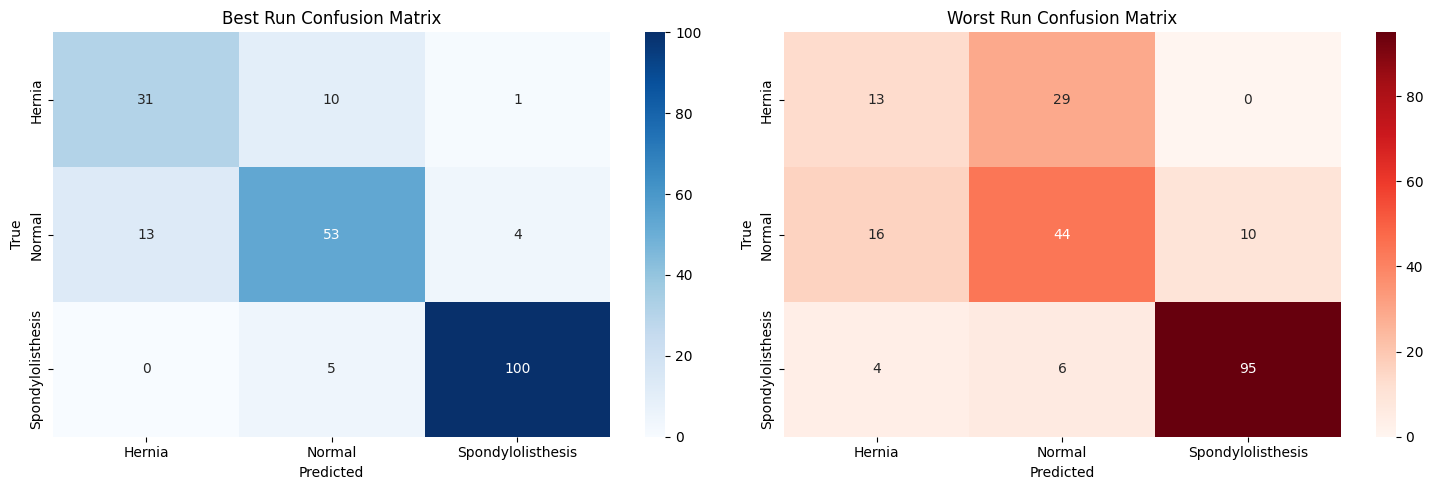

Classification Report for Best Run (#1):
                   precision    recall  f1-score   support

           Hernia       0.70      0.74      0.72        42
           Normal       0.78      0.76      0.77        70
Spondylolisthesis       0.95      0.95      0.95       105

         accuracy                           0.85       217
        macro avg       0.81      0.82      0.81       217
     weighted avg       0.85      0.85      0.85       217

--- KNN (m=1.50) ---
Best Run (#1) Accuracy: 0.8618
Worst Run (#49) Accuracy: 0.6912


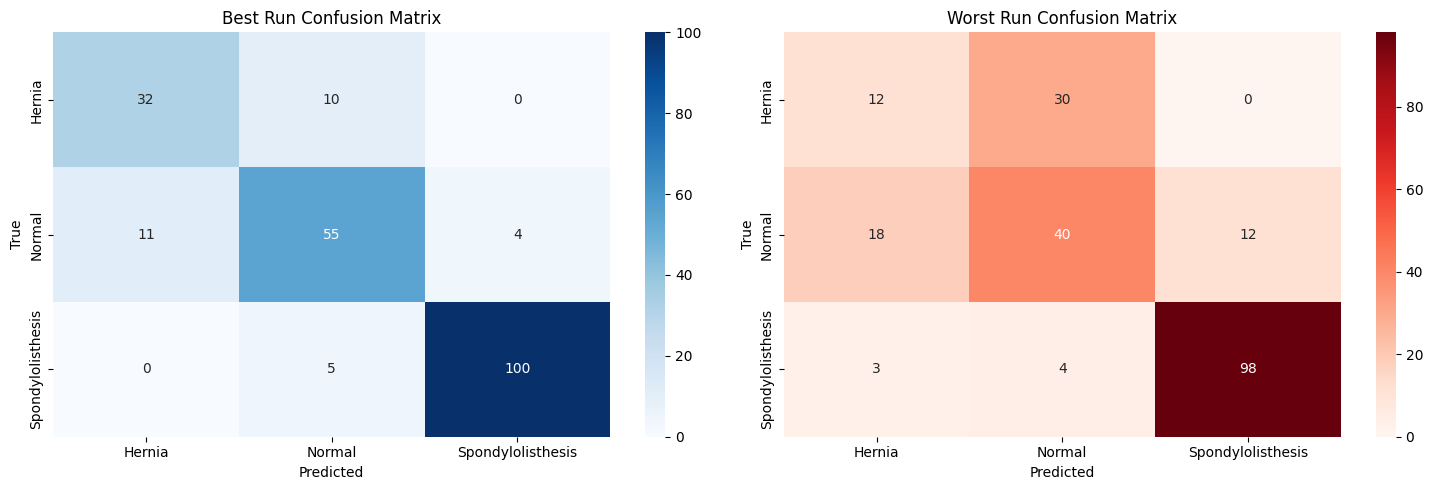

Classification Report for Best Run (#1):
                   precision    recall  f1-score   support

           Hernia       0.74      0.76      0.75        42
           Normal       0.79      0.79      0.79        70
Spondylolisthesis       0.96      0.95      0.96       105

         accuracy                           0.86       217
        macro avg       0.83      0.83      0.83       217
     weighted avg       0.86      0.86      0.86       217

--- KNN (m=2.00) ---
Best Run (#6) Accuracy: 0.8571
Worst Run (#42) Accuracy: 0.7143


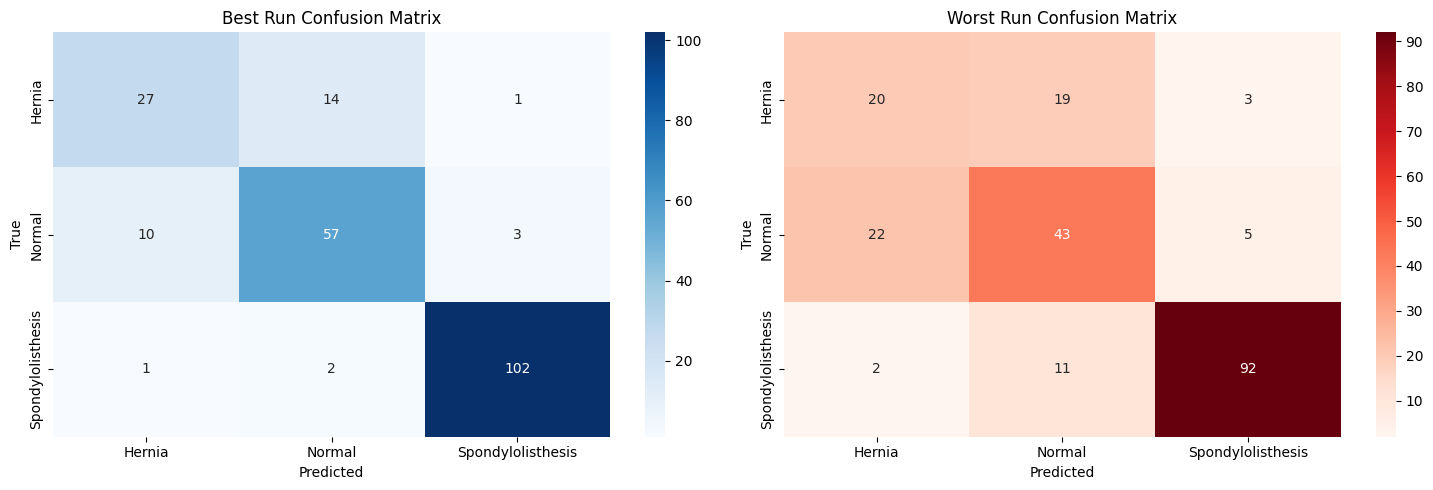

Classification Report for Best Run (#6):
                   precision    recall  f1-score   support

           Hernia       0.71      0.64      0.68        42
           Normal       0.78      0.81      0.80        70
Spondylolisthesis       0.96      0.97      0.97       105

         accuracy                           0.86       217
        macro avg       0.82      0.81      0.81       217
     weighted avg       0.86      0.86      0.86       217

--- KNN (m=2.50) ---
Best Run (#8) Accuracy: 0.8525
Worst Run (#42) Accuracy: 0.6959


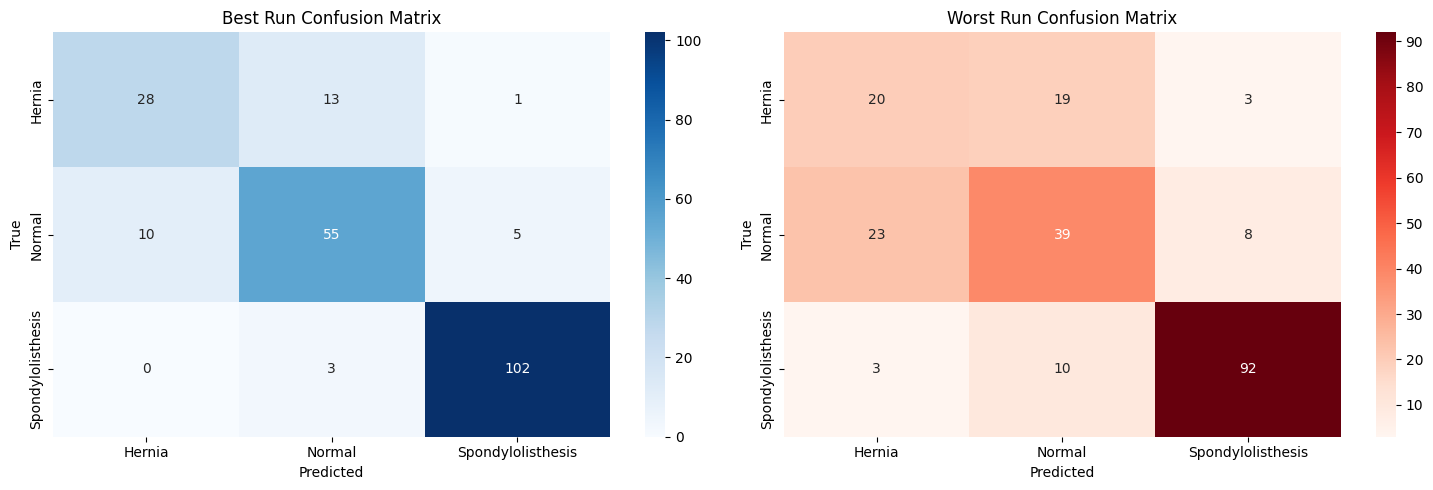

Classification Report for Best Run (#8):
                   precision    recall  f1-score   support

           Hernia       0.74      0.67      0.70        42
           Normal       0.77      0.79      0.78        70
Spondylolisthesis       0.94      0.97      0.96       105

         accuracy                           0.85       217
        macro avg       0.82      0.81      0.81       217
     weighted avg       0.85      0.85      0.85       217

--- MDC ---
Best Run (#59) Accuracy: 0.8433
Worst Run (#49) Accuracy: 0.6636


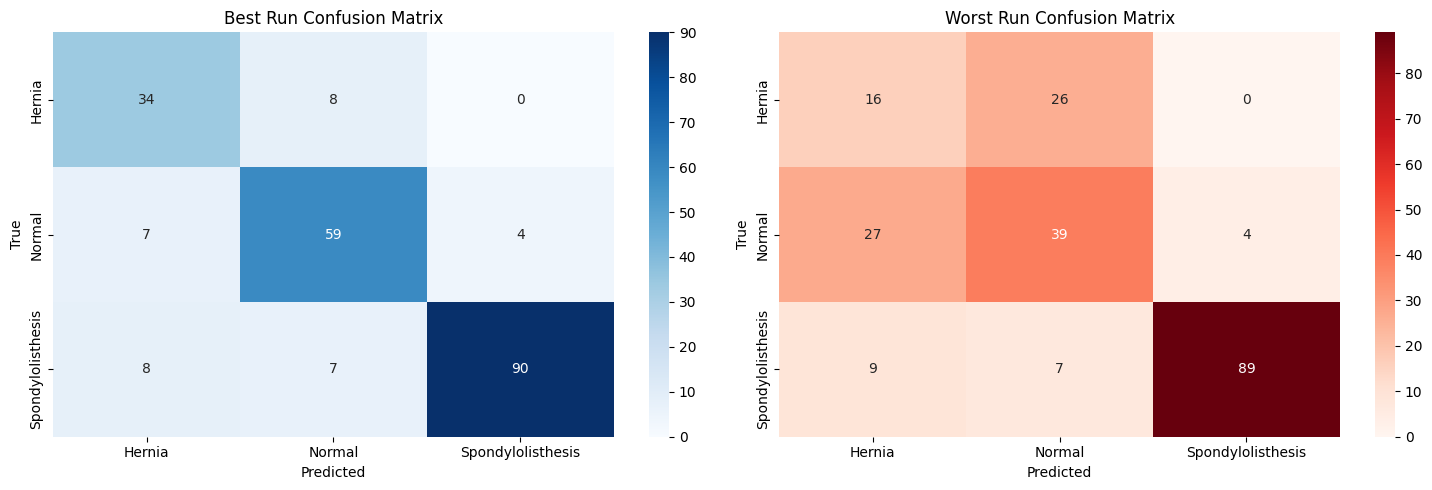

Classification Report for Best Run (#59):
                   precision    recall  f1-score   support

           Hernia       0.69      0.81      0.75        42
           Normal       0.80      0.84      0.82        70
Spondylolisthesis       0.96      0.86      0.90       105

         accuracy                           0.84       217
        macro avg       0.82      0.84      0.82       217
     weighted avg       0.85      0.84      0.85       217

--- MDC Robusto ---
Best Run (#6) Accuracy: 0.8387
Worst Run (#49) Accuracy: 0.6498


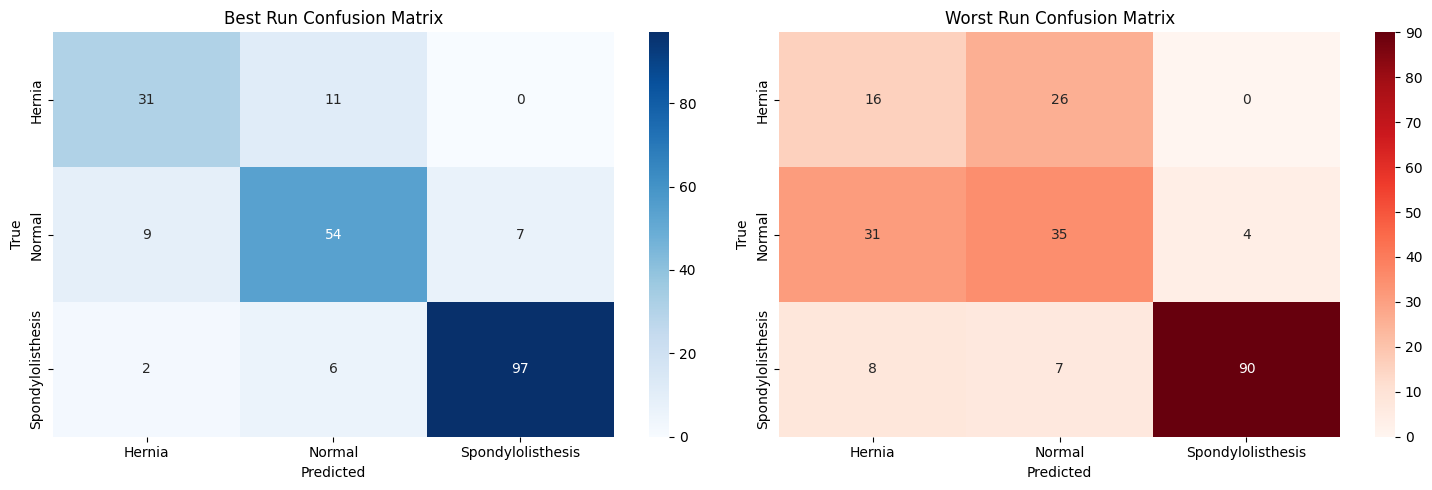

Classification Report for Best Run (#6):
                   precision    recall  f1-score   support

           Hernia       0.74      0.74      0.74        42
           Normal       0.76      0.77      0.77        70
Spondylolisthesis       0.93      0.92      0.93       105

         accuracy                           0.84       217
        macro avg       0.81      0.81      0.81       217
     weighted avg       0.84      0.84      0.84       217

--- MAXCO ---
Best Run (#69) Accuracy: 0.8295
Worst Run (#49) Accuracy: 0.5991


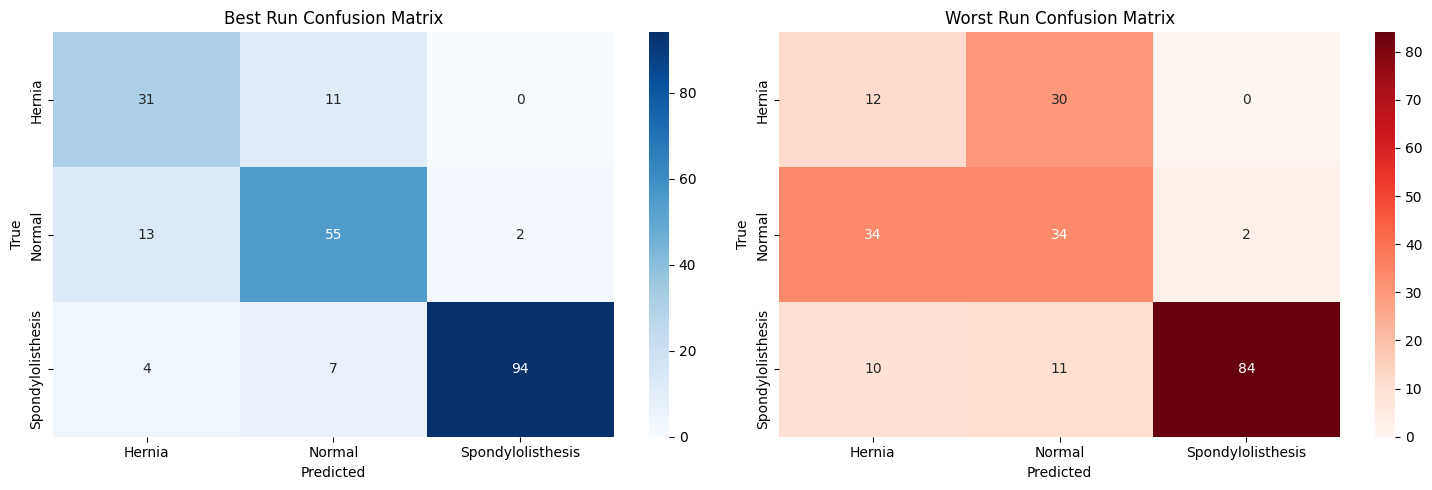

Classification Report for Best Run (#69):
                   precision    recall  f1-score   support

           Hernia       0.65      0.74      0.69        42
           Normal       0.75      0.79      0.77        70
Spondylolisthesis       0.98      0.90      0.94       105

         accuracy                           0.83       217
        macro avg       0.79      0.81      0.80       217
     weighted avg       0.84      0.83      0.83       217

   Running Experiments for Train/Test Split: 50/50   


,Classifier,Mean Accuracy,Std Accuracy,Min Accuracy,Max Accuracy,Median Accuracy,Mean Train Time (s),Mean Test Time (s)
4,KNN (m=2.00),0.806581,0.027265,0.741935,0.890323,0.806452,0.000003,0.004007
5,KNN (m=2.50),0.806194,0.026880,0.741935,0.883871,0.806452,0.000004,0.004347
3,KNN (m=1.50),0.804065,0.027834,0.754839,0.890323,0.806452,0.000004,0.004371
2,KNN (m=1.00),0.797677,0.029403,0.722581,0.877419,0.796774,0.000004,0.004043
7,MDC Robusto,0.785548,0.028840,0.696774,0.851613,0.787097,0.000154,0.000879
1,KNN (m=0.67),0.779613,0.027169,0.703226,0.864516,0.780645,0.000004,0.004289
6,MDC,0.770645,0.033751,0.677419,0.851613,0.774194,0.000080,0.000888
0,KNN (m=0.50),0.766774,0.028098,0.696774,0.838710,0.767742,0.000007,0.004008
8,MAXCO,0.723484,0.036610,0.619355,0.800000,0.722581,0.000059,0.005579


--- KNN (m=0.50) ---
Best Run (#47) Accuracy: 0.8387
Worst Run (#59) Accuracy: 0.6968


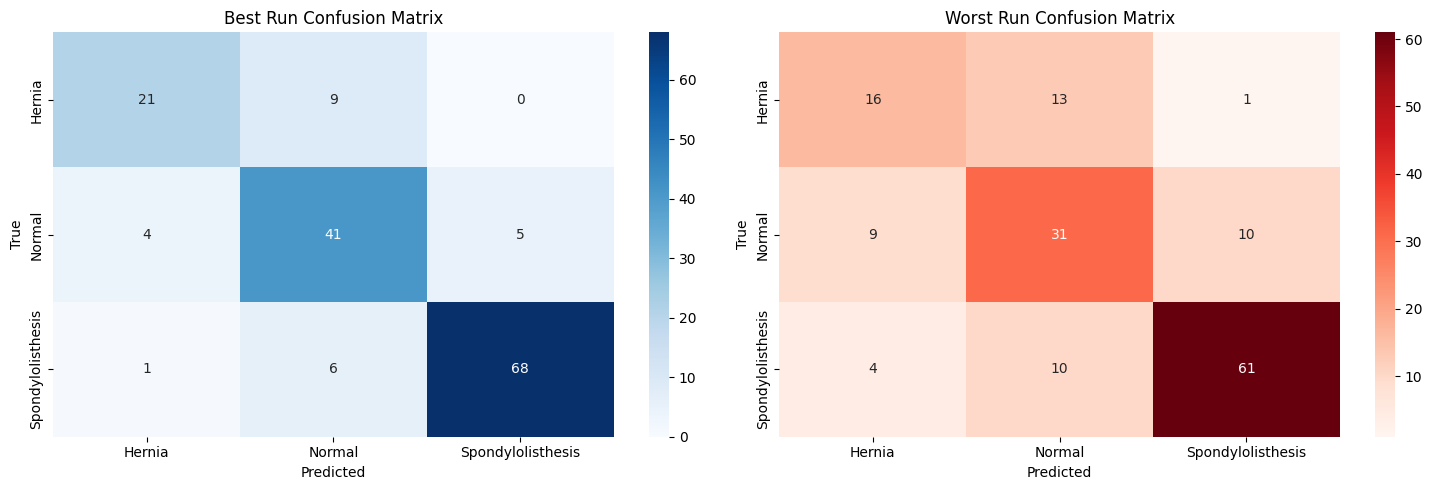

Classification Report for Best Run (#47):
                   precision    recall  f1-score   support

           Hernia       0.81      0.70      0.75        30
           Normal       0.73      0.82      0.77        50
Spondylolisthesis       0.93      0.91      0.92        75

         accuracy                           0.84       155
        macro avg       0.82      0.81      0.81       155
     weighted avg       0.84      0.84      0.84       155

--- KNN (m=0.67) ---
Best Run (#47) Accuracy: 0.8645
Worst Run (#59) Accuracy: 0.7032


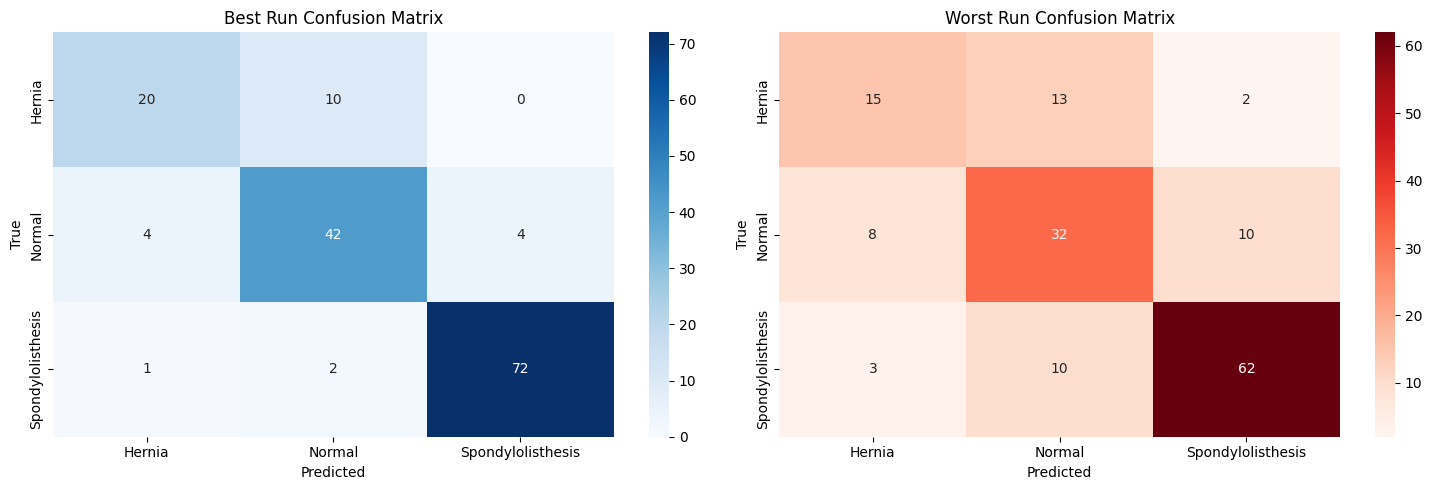

Classification Report for Best Run (#47):
                   precision    recall  f1-score   support

           Hernia       0.80      0.67      0.73        30
           Normal       0.78      0.84      0.81        50
Spondylolisthesis       0.95      0.96      0.95        75

         accuracy                           0.86       155
        macro avg       0.84      0.82      0.83       155
     weighted avg       0.86      0.86      0.86       155

--- KNN (m=1.00) ---
Best Run (#56) Accuracy: 0.8774
Worst Run (#43) Accuracy: 0.7226


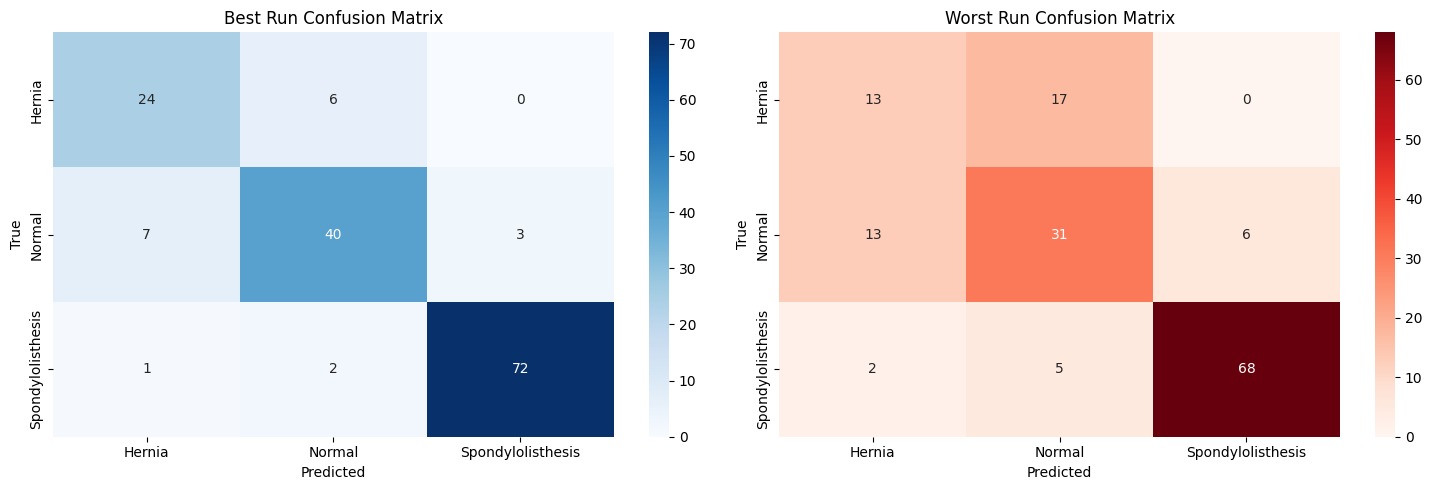

Classification Report for Best Run (#56):
                   precision    recall  f1-score   support

           Hernia       0.75      0.80      0.77        30
           Normal       0.83      0.80      0.82        50
Spondylolisthesis       0.96      0.96      0.96        75

         accuracy                           0.88       155
        macro avg       0.85      0.85      0.85       155
     weighted avg       0.88      0.88      0.88       155

--- KNN (m=1.50) ---
Best Run (#56) Accuracy: 0.8903
Worst Run (#11) Accuracy: 0.7548


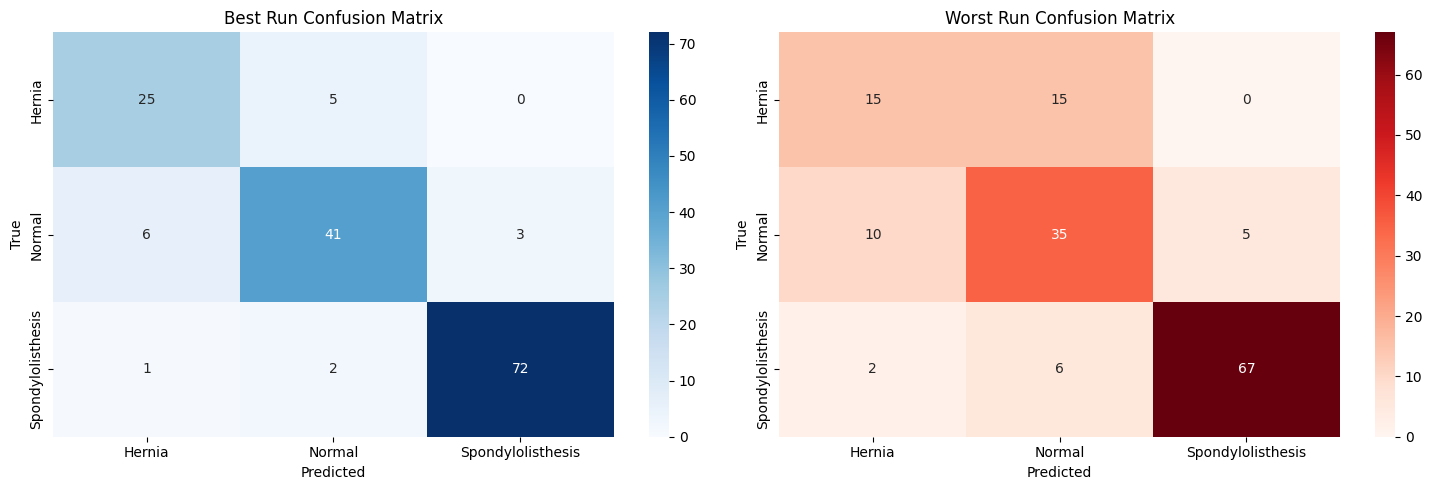

Classification Report for Best Run (#56):
                   precision    recall  f1-score   support

           Hernia       0.78      0.83      0.81        30
           Normal       0.85      0.82      0.84        50
Spondylolisthesis       0.96      0.96      0.96        75

         accuracy                           0.89       155
        macro avg       0.87      0.87      0.87       155
     weighted avg       0.89      0.89      0.89       155

--- KNN (m=2.00) ---
Best Run (#4) Accuracy: 0.8903
Worst Run (#11) Accuracy: 0.7419


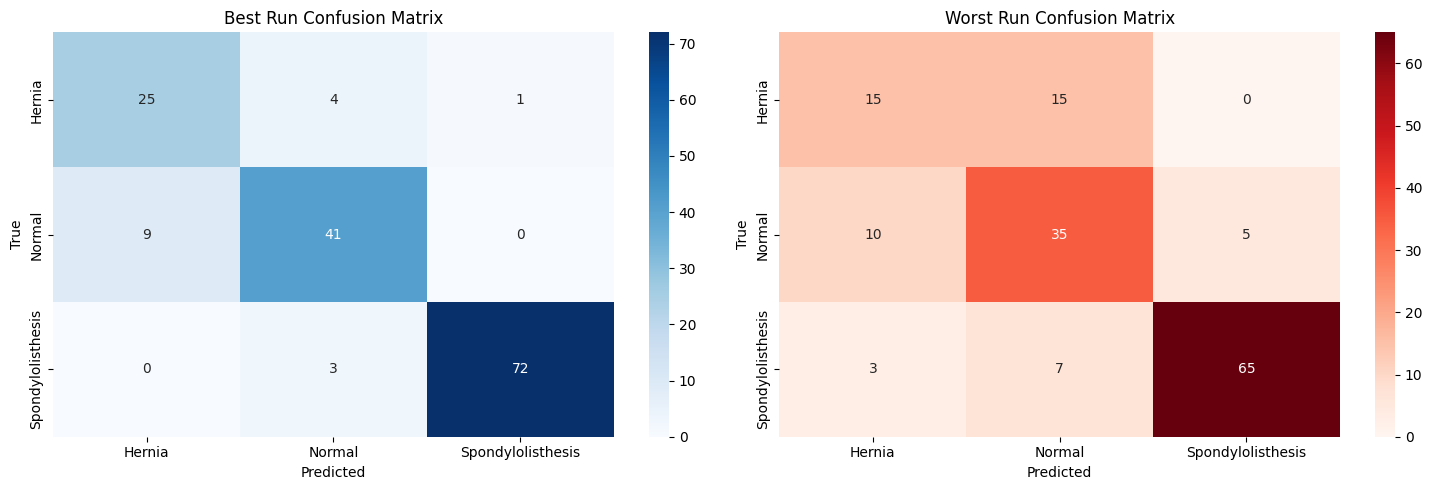

Classification Report for Best Run (#4):
                   precision    recall  f1-score   support

           Hernia       0.74      0.83      0.78        30
           Normal       0.85      0.82      0.84        50
Spondylolisthesis       0.99      0.96      0.97        75

         accuracy                           0.89       155
        macro avg       0.86      0.87      0.86       155
     weighted avg       0.90      0.89      0.89       155

--- KNN (m=2.50) ---
Best Run (#4) Accuracy: 0.8839
Worst Run (#11) Accuracy: 0.7419


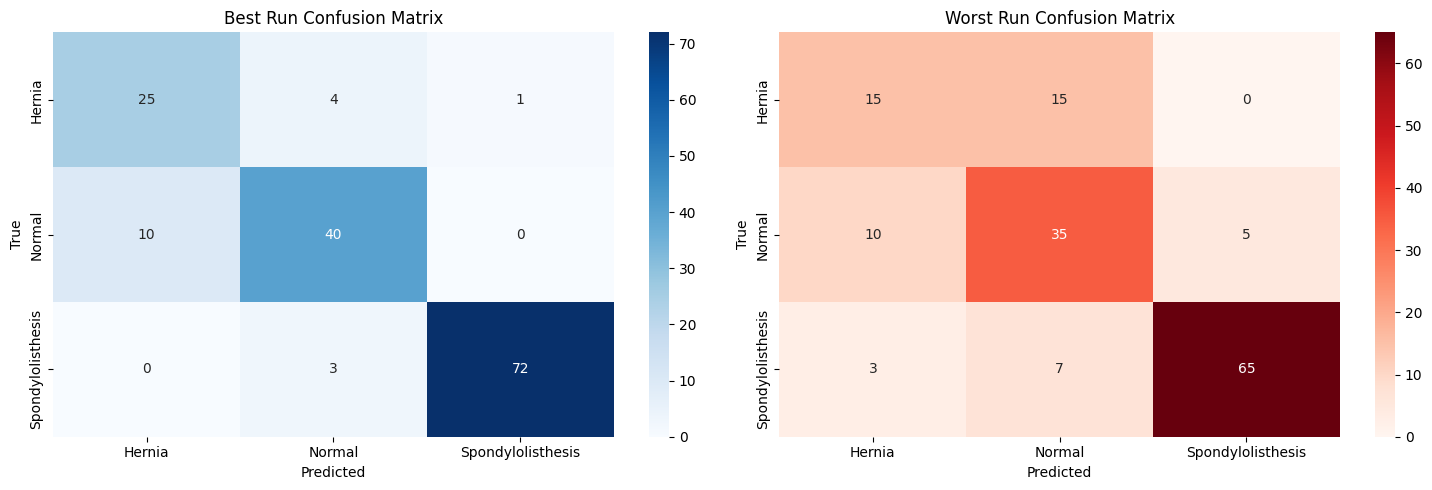

Classification Report for Best Run (#4):
                   precision    recall  f1-score   support

           Hernia       0.71      0.83      0.77        30
           Normal       0.85      0.80      0.82        50
Spondylolisthesis       0.99      0.96      0.97        75

         accuracy                           0.88       155
        macro avg       0.85      0.86      0.86       155
     weighted avg       0.89      0.88      0.89       155

--- MDC ---
Best Run (#24) Accuracy: 0.8516
Worst Run (#94) Accuracy: 0.6774


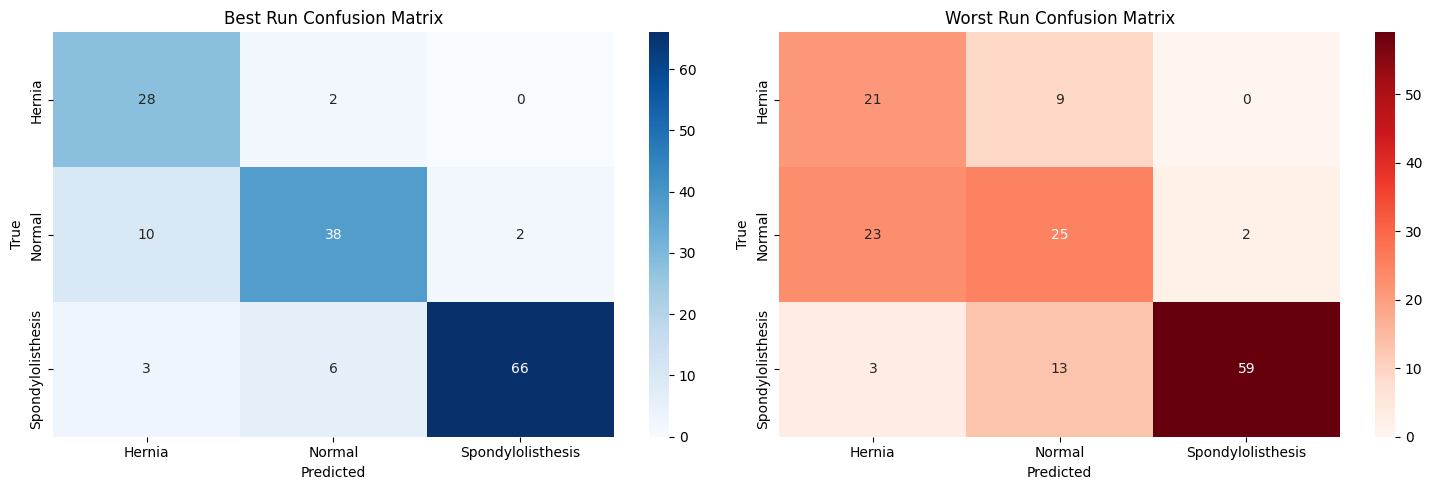

Classification Report for Best Run (#24):
                   precision    recall  f1-score   support

           Hernia       0.68      0.93      0.79        30
           Normal       0.83      0.76      0.79        50
Spondylolisthesis       0.97      0.88      0.92        75

         accuracy                           0.85       155
        macro avg       0.83      0.86      0.83       155
     weighted avg       0.87      0.85      0.85       155

--- MDC Robusto ---
Best Run (#56) Accuracy: 0.8516
Worst Run (#54) Accuracy: 0.6968


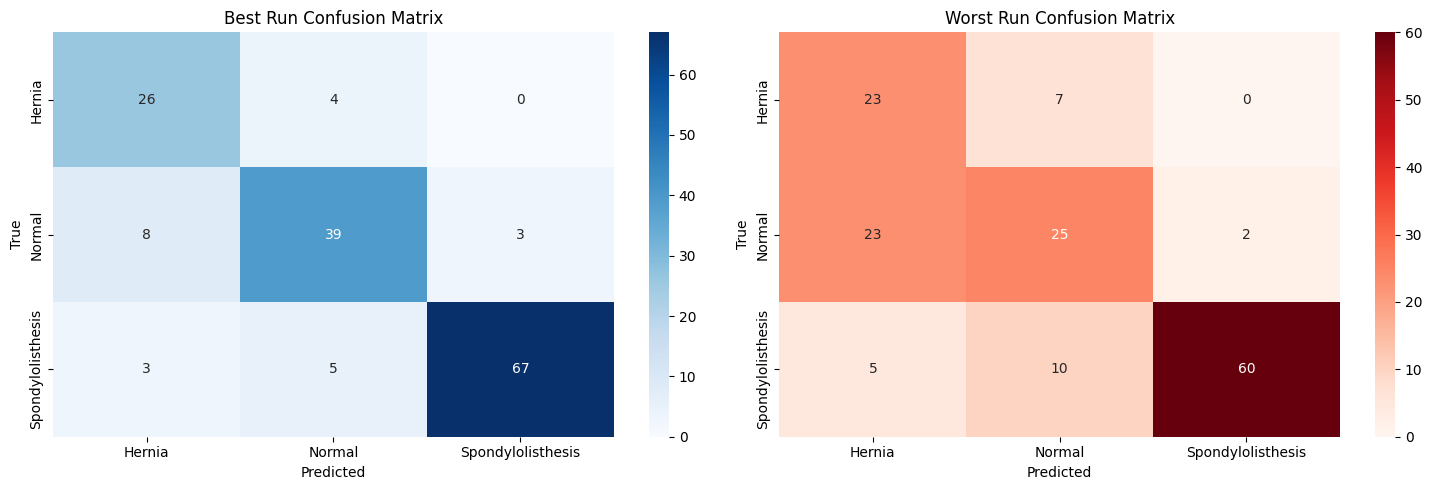

Classification Report for Best Run (#56):
                   precision    recall  f1-score   support

           Hernia       0.70      0.87      0.78        30
           Normal       0.81      0.78      0.80        50
Spondylolisthesis       0.96      0.89      0.92        75

         accuracy                           0.85       155
        macro avg       0.82      0.85      0.83       155
     weighted avg       0.86      0.85      0.85       155

--- MAXCO ---
Best Run (#83) Accuracy: 0.8000
Worst Run (#54) Accuracy: 0.6194


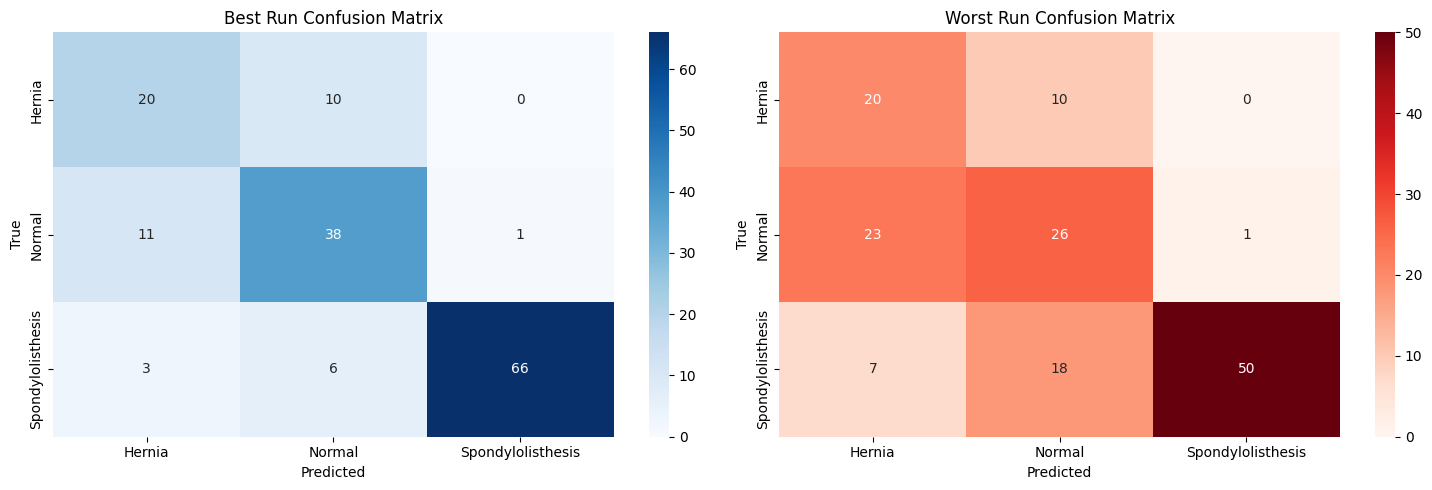

Classification Report for Best Run (#83):
                   precision    recall  f1-score   support

           Hernia       0.59      0.67      0.62        30
           Normal       0.70      0.76      0.73        50
Spondylolisthesis       0.99      0.88      0.93        75

         accuracy                           0.80       155
        macro avg       0.76      0.77      0.76       155
     weighted avg       0.82      0.80      0.81       155

   Running Experiments for Train/Test Split: 70/30   


,Classifier,Mean Accuracy,Std Accuracy,Min Accuracy,Max Accuracy,Median Accuracy,Mean Train Time (s),Mean Test Time (s)
5,KNN (m=2.50),0.814409,0.034463,0.752688,0.903226,0.806452,0.000004,0.002982
4,KNN (m=2.00),0.812151,0.035352,0.741935,0.892473,0.806452,0.000004,0.002676
3,KNN (m=1.50),0.807849,0.033923,0.731183,0.903226,0.806452,0.000004,0.003065
2,KNN (m=1.00),0.805699,0.037473,0.709677,0.913978,0.806452,0.000004,0.002712
7,MDC Robusto,0.786667,0.037364,0.698925,0.870968,0.795699,0.000169,0.000557
1,KNN (m=0.67),0.780860,0.037918,0.655914,0.870968,0.784946,0.000005,0.003036
6,MDC,0.765914,0.039679,0.655914,0.870968,0.763441,0.000088,0.000557
0,KNN (m=0.50),0.765699,0.038927,0.655914,0.860215,0.774194,0.000006,0.002723
8,MAXCO,0.722043,0.046158,0.580645,0.849462,0.720430,0.000066,0.003427


--- KNN (m=0.50) ---
Best Run (#98) Accuracy: 0.8602
Worst Run (#57) Accuracy: 0.6559


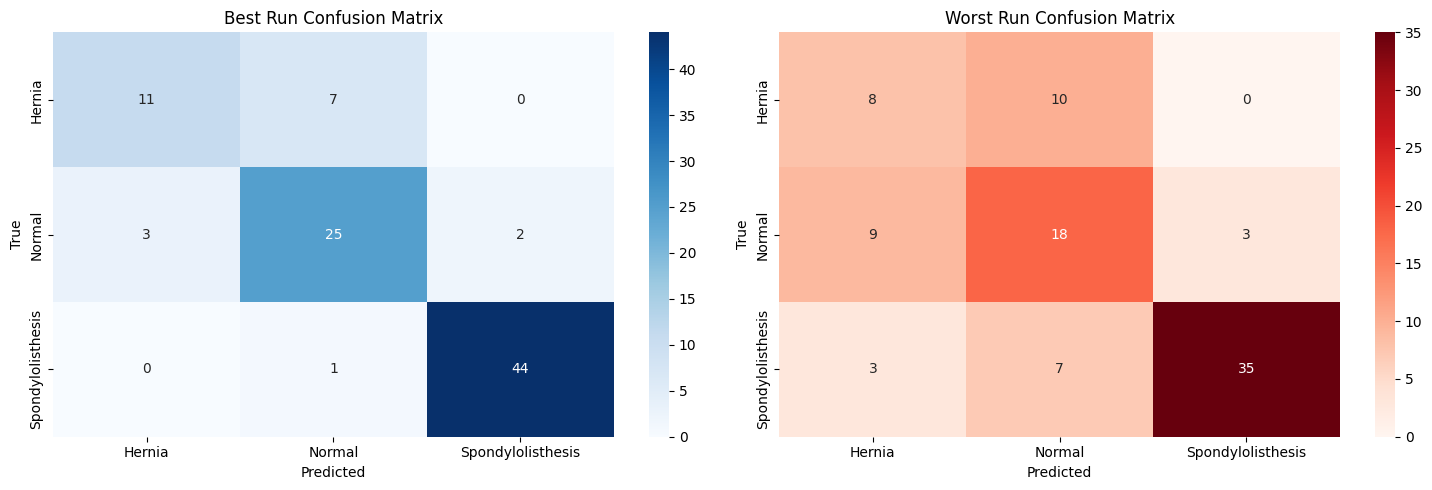

Classification Report for Best Run (#98):
                   precision    recall  f1-score   support

           Hernia       0.79      0.61      0.69        18
           Normal       0.76      0.83      0.79        30
Spondylolisthesis       0.96      0.98      0.97        45

         accuracy                           0.86        93
        macro avg       0.83      0.81      0.82        93
     weighted avg       0.86      0.86      0.86        93

--- KNN (m=0.67) ---
Best Run (#47) Accuracy: 0.8710
Worst Run (#57) Accuracy: 0.6559


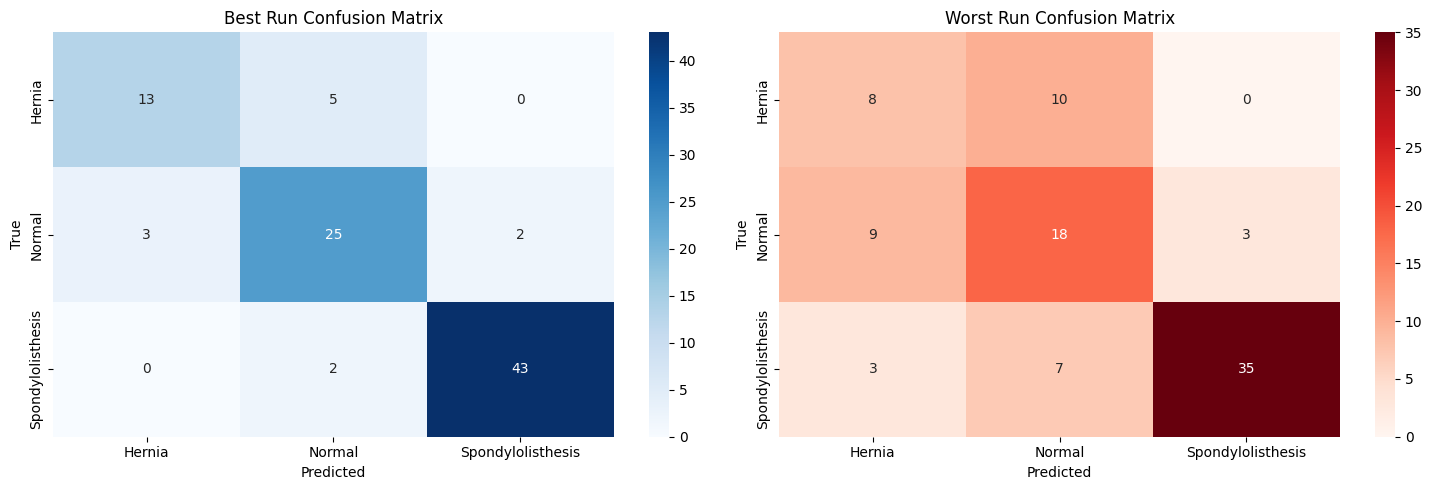

Classification Report for Best Run (#47):
                   precision    recall  f1-score   support

           Hernia       0.81      0.72      0.76        18
           Normal       0.78      0.83      0.81        30
Spondylolisthesis       0.96      0.96      0.96        45

         accuracy                           0.87        93
        macro avg       0.85      0.84      0.84        93
     weighted avg       0.87      0.87      0.87        93

--- KNN (m=1.00) ---
Best Run (#65) Accuracy: 0.9140
Worst Run (#12) Accuracy: 0.7097


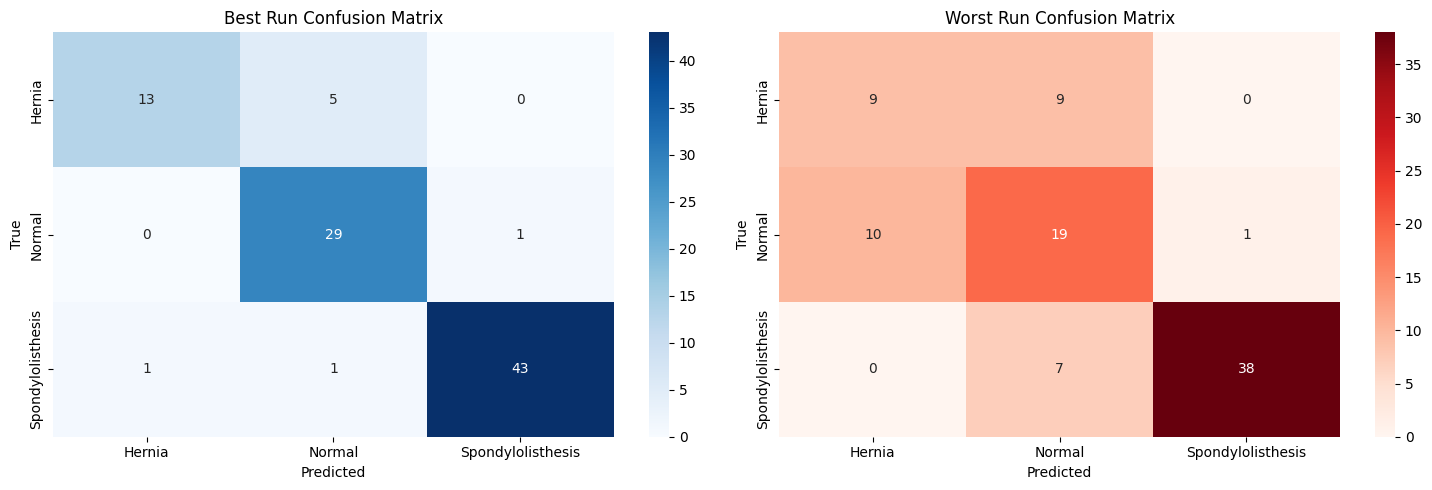

Classification Report for Best Run (#65):
                   precision    recall  f1-score   support

           Hernia       0.93      0.72      0.81        18
           Normal       0.83      0.97      0.89        30
Spondylolisthesis       0.98      0.96      0.97        45

         accuracy                           0.91        93
        macro avg       0.91      0.88      0.89        93
     weighted avg       0.92      0.91      0.91        93

--- KNN (m=1.50) ---
Best Run (#65) Accuracy: 0.9032
Worst Run (#29) Accuracy: 0.7312


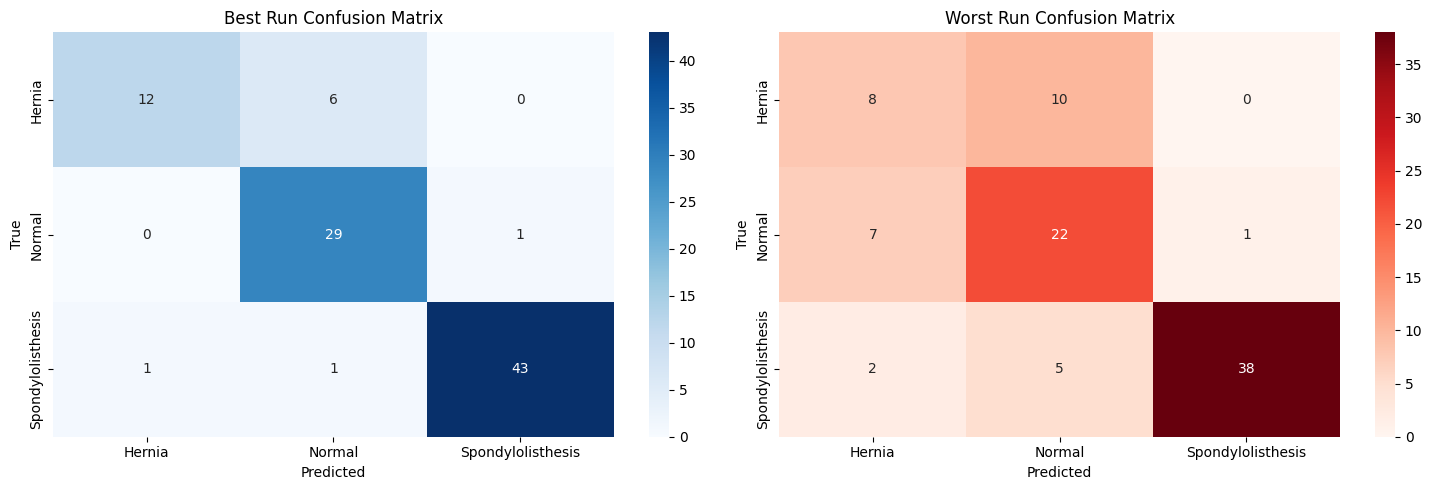

Classification Report for Best Run (#65):
                   precision    recall  f1-score   support

           Hernia       0.92      0.67      0.77        18
           Normal       0.81      0.97      0.88        30
Spondylolisthesis       0.98      0.96      0.97        45

         accuracy                           0.90        93
        macro avg       0.90      0.86      0.87        93
     weighted avg       0.91      0.90      0.90        93

--- KNN (m=2.00) ---
Best Run (#23) Accuracy: 0.8925
Worst Run (#3) Accuracy: 0.7419


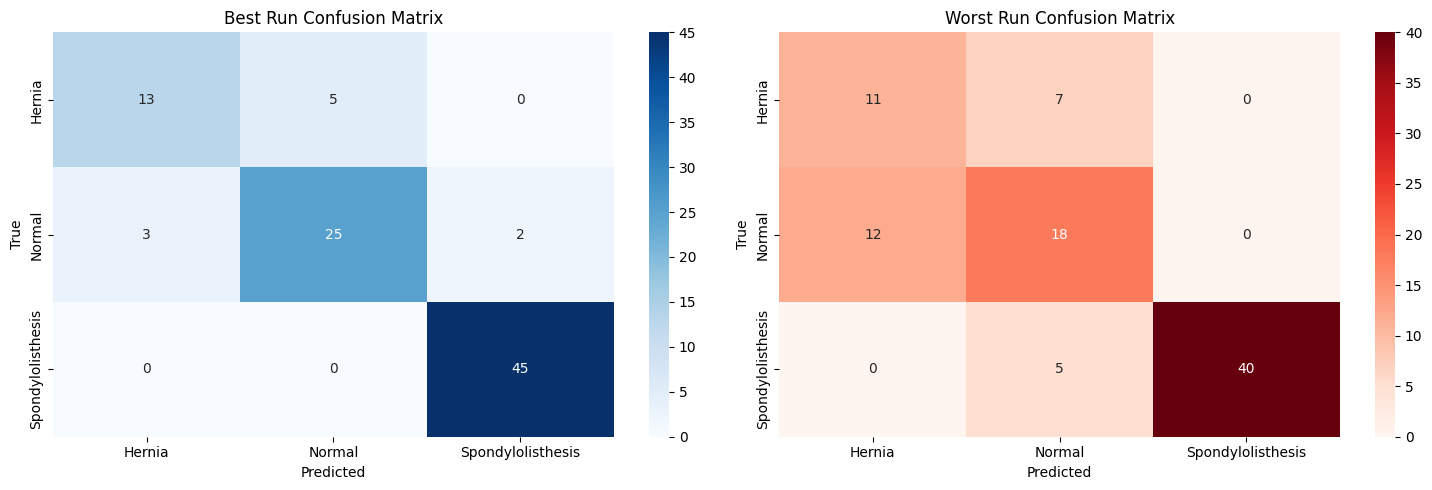

Classification Report for Best Run (#23):
                   precision    recall  f1-score   support

           Hernia       0.81      0.72      0.76        18
           Normal       0.83      0.83      0.83        30
Spondylolisthesis       0.96      1.00      0.98        45

         accuracy                           0.89        93
        macro avg       0.87      0.85      0.86        93
     weighted avg       0.89      0.89      0.89        93

--- KNN (m=2.50) ---
Best Run (#99) Accuracy: 0.9032
Worst Run (#12) Accuracy: 0.7527


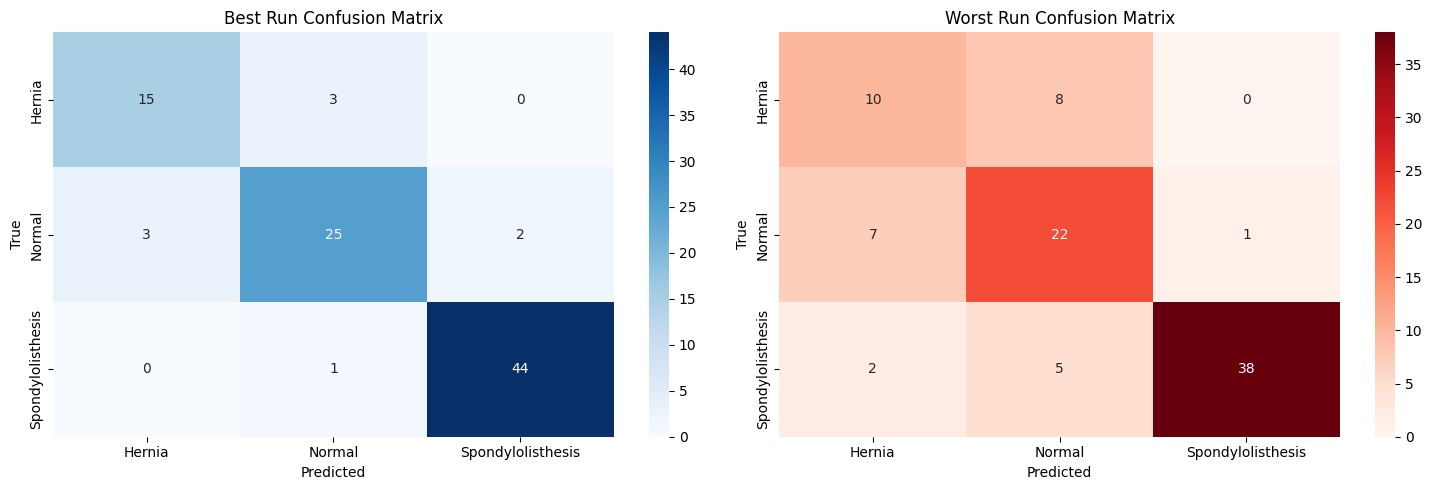

Classification Report for Best Run (#99):
                   precision    recall  f1-score   support

           Hernia       0.83      0.83      0.83        18
           Normal       0.86      0.83      0.85        30
Spondylolisthesis       0.96      0.98      0.97        45

         accuracy                           0.90        93
        macro avg       0.88      0.88      0.88        93
     weighted avg       0.90      0.90      0.90        93

--- MDC ---
Best Run (#28) Accuracy: 0.8710
Worst Run (#3) Accuracy: 0.6559


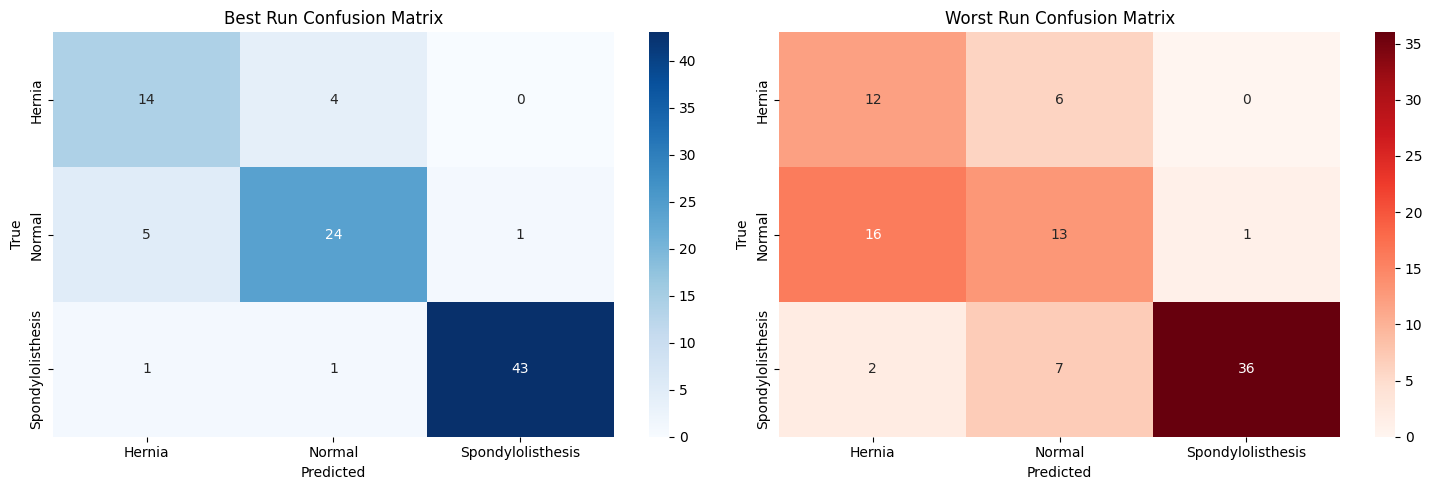

Classification Report for Best Run (#28):
                   precision    recall  f1-score   support

           Hernia       0.70      0.78      0.74        18
           Normal       0.83      0.80      0.81        30
Spondylolisthesis       0.98      0.96      0.97        45

         accuracy                           0.87        93
        macro avg       0.83      0.84      0.84        93
     weighted avg       0.88      0.87      0.87        93

--- MDC Robusto ---
Best Run (#80) Accuracy: 0.8710
Worst Run (#3) Accuracy: 0.6989


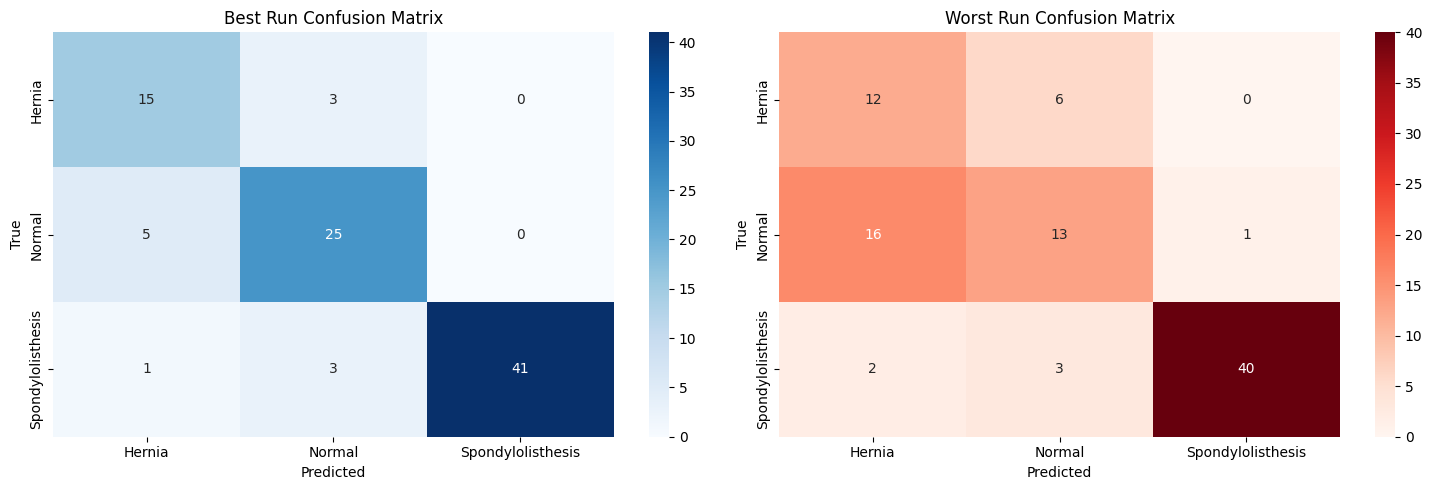

Classification Report for Best Run (#80):
                   precision    recall  f1-score   support

           Hernia       0.71      0.83      0.77        18
           Normal       0.81      0.83      0.82        30
Spondylolisthesis       1.00      0.91      0.95        45

         accuracy                           0.87        93
        macro avg       0.84      0.86      0.85        93
     weighted avg       0.88      0.87      0.87        93

--- MAXCO ---
Best Run (#79) Accuracy: 0.8495
Worst Run (#22) Accuracy: 0.5806


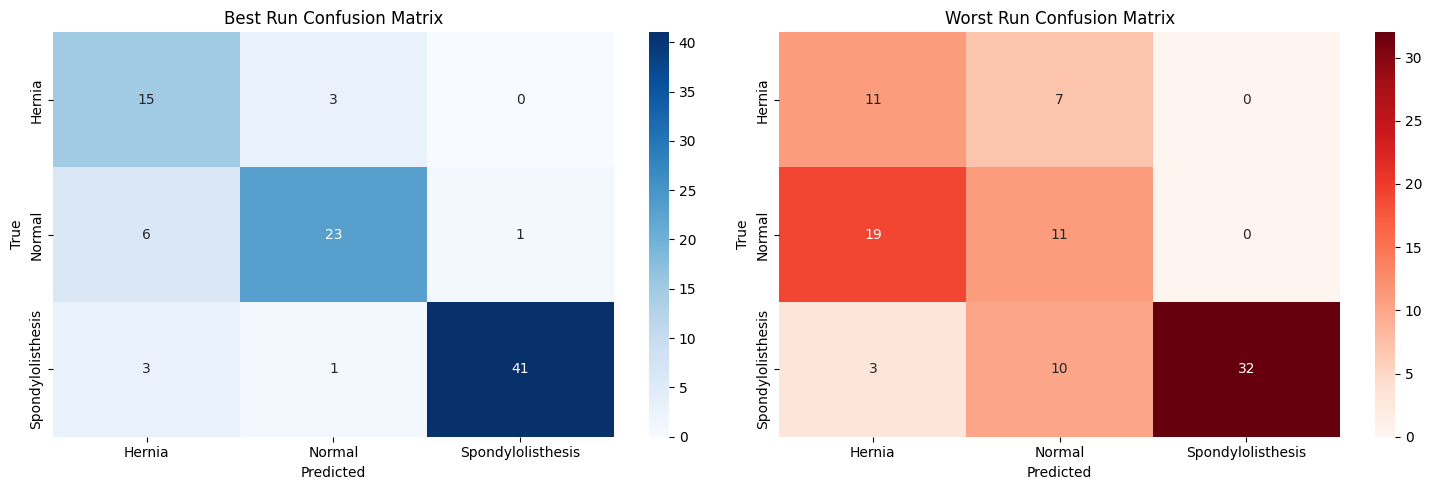

Classification Report for Best Run (#79):
                   precision    recall  f1-score   support

           Hernia       0.62      0.83      0.71        18
           Normal       0.85      0.77      0.81        30
Spondylolisthesis       0.98      0.91      0.94        45

         accuracy                           0.85        93
        macro avg       0.82      0.84      0.82        93
     weighted avg       0.87      0.85      0.85        93

   Running Experiments for Train/Test Split: 80/20   


,Classifier,Mean Accuracy,Std Accuracy,Min Accuracy,Max Accuracy,Median Accuracy,Mean Train Time (s),Mean Test Time (s)
5,KNN (m=2.50),0.823871,0.042040,0.725806,0.919355,0.822581,0.000004,0.002106
4,KNN (m=2.00),0.820968,0.042275,0.693548,0.903226,0.822581,0.000003,0.001816
3,KNN (m=1.50),0.816129,0.041624,0.725806,0.903226,0.806452,0.000004,0.002069
2,KNN (m=1.00),0.815806,0.041196,0.709677,0.935484,0.814516,0.000003,0.001818
7,MDC Robusto,0.786129,0.045024,0.677419,0.870968,0.782258,0.000170,0.000368
1,KNN (m=0.67),0.784516,0.048949,0.629032,0.903226,0.790323,0.000004,0.002049
0,KNN (m=0.50),0.765484,0.045243,0.645161,0.870968,0.758065,0.000005,0.001831
6,MDC,0.762903,0.046495,0.661290,0.887097,0.774194,0.000088,0.000366
8,MAXCO,0.722097,0.060084,0.564516,0.887097,0.709677,0.000063,0.002238


--- KNN (m=0.50) ---
Best Run (#92) Accuracy: 0.8710
Worst Run (#30) Accuracy: 0.6452


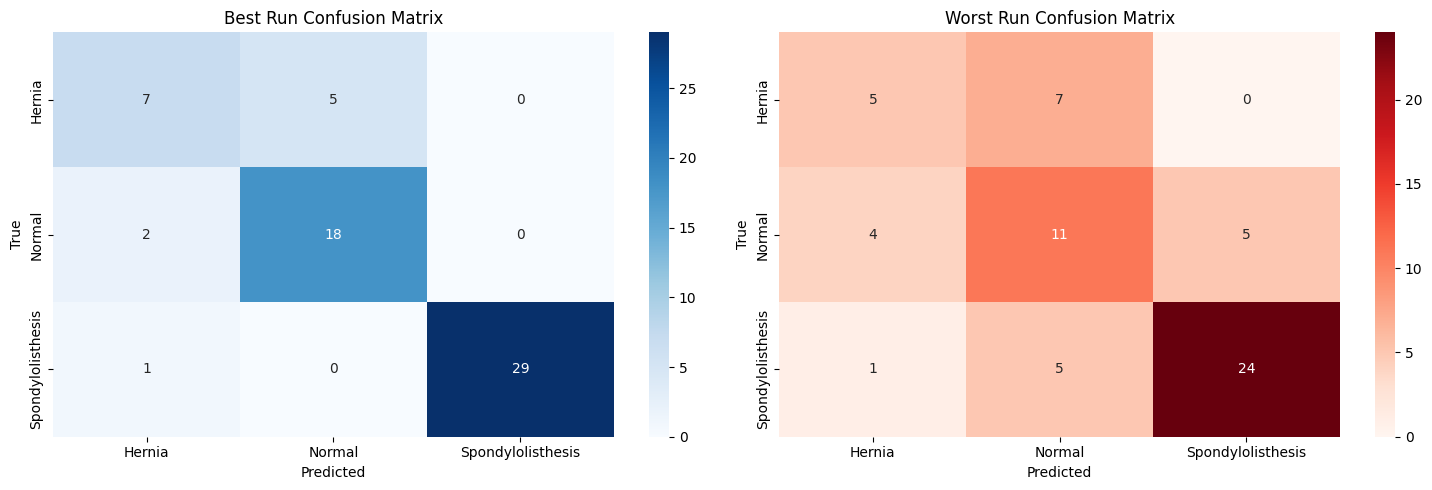

Classification Report for Best Run (#92):
                   precision    recall  f1-score   support

           Hernia       0.70      0.58      0.64        12
           Normal       0.78      0.90      0.84        20
Spondylolisthesis       1.00      0.97      0.98        30

         accuracy                           0.87        62
        macro avg       0.83      0.82      0.82        62
     weighted avg       0.87      0.87      0.87        62

--- KNN (m=0.67) ---
Best Run (#47) Accuracy: 0.9032
Worst Run (#30) Accuracy: 0.6290


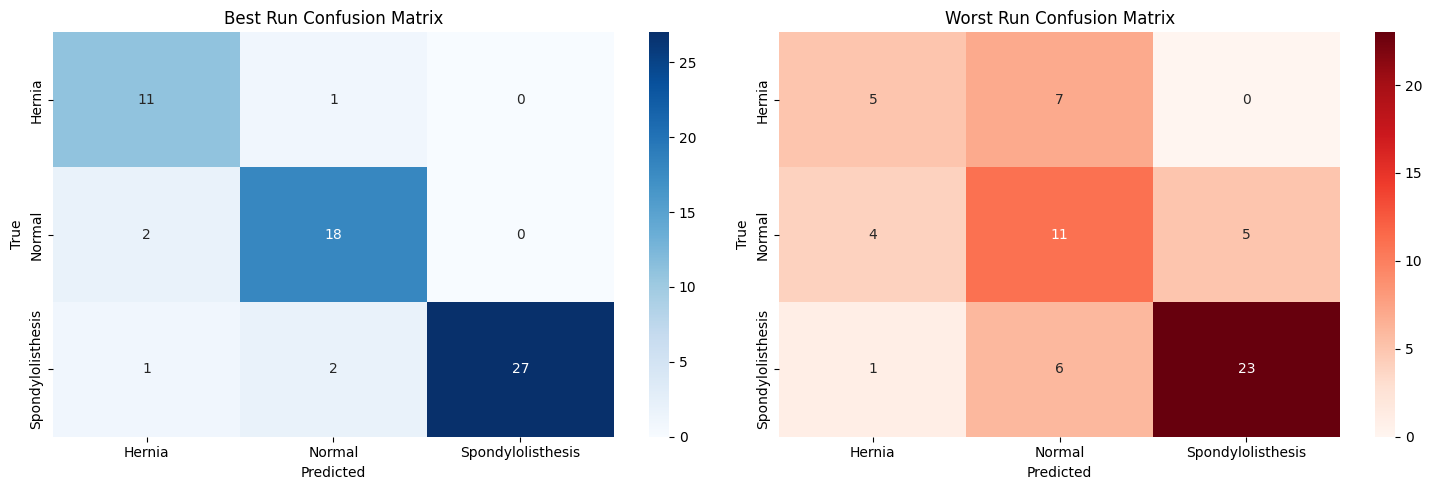

Classification Report for Best Run (#47):
                   precision    recall  f1-score   support

           Hernia       0.79      0.92      0.85        12
           Normal       0.86      0.90      0.88        20
Spondylolisthesis       1.00      0.90      0.95        30

         accuracy                           0.90        62
        macro avg       0.88      0.91      0.89        62
     weighted avg       0.91      0.90      0.91        62

--- KNN (m=1.00) ---
Best Run (#47) Accuracy: 0.9355
Worst Run (#96) Accuracy: 0.7097


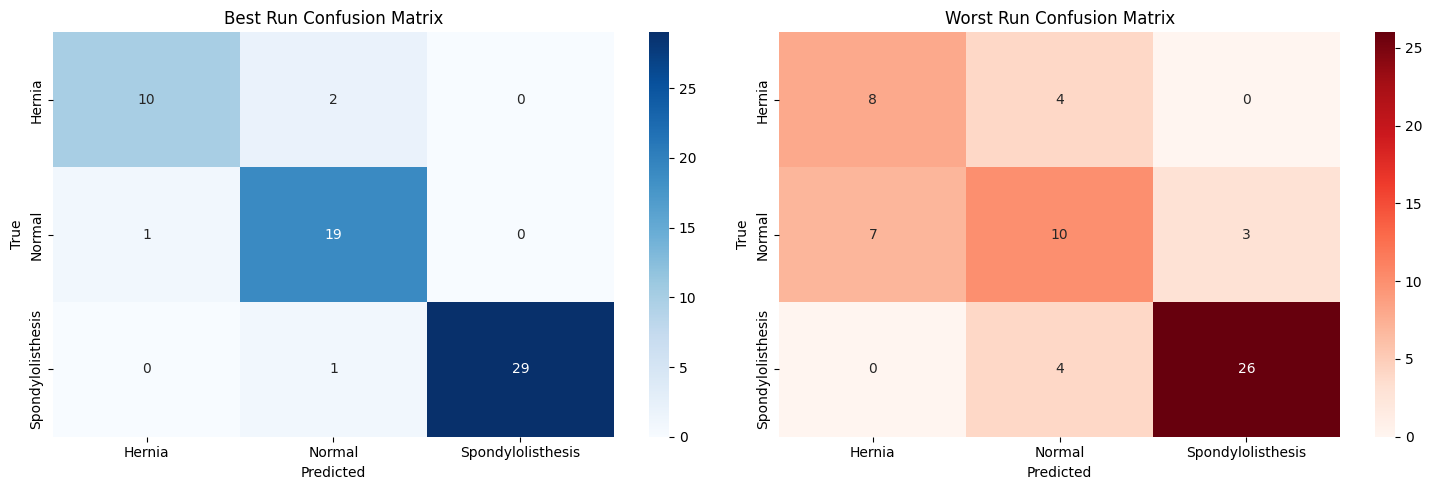

Classification Report for Best Run (#47):
                   precision    recall  f1-score   support

           Hernia       0.91      0.83      0.87        12
           Normal       0.86      0.95      0.90        20
Spondylolisthesis       1.00      0.97      0.98        30

         accuracy                           0.94        62
        macro avg       0.92      0.92      0.92        62
     weighted avg       0.94      0.94      0.94        62

--- KNN (m=1.50) ---
Best Run (#55) Accuracy: 0.9032
Worst Run (#29) Accuracy: 0.7258


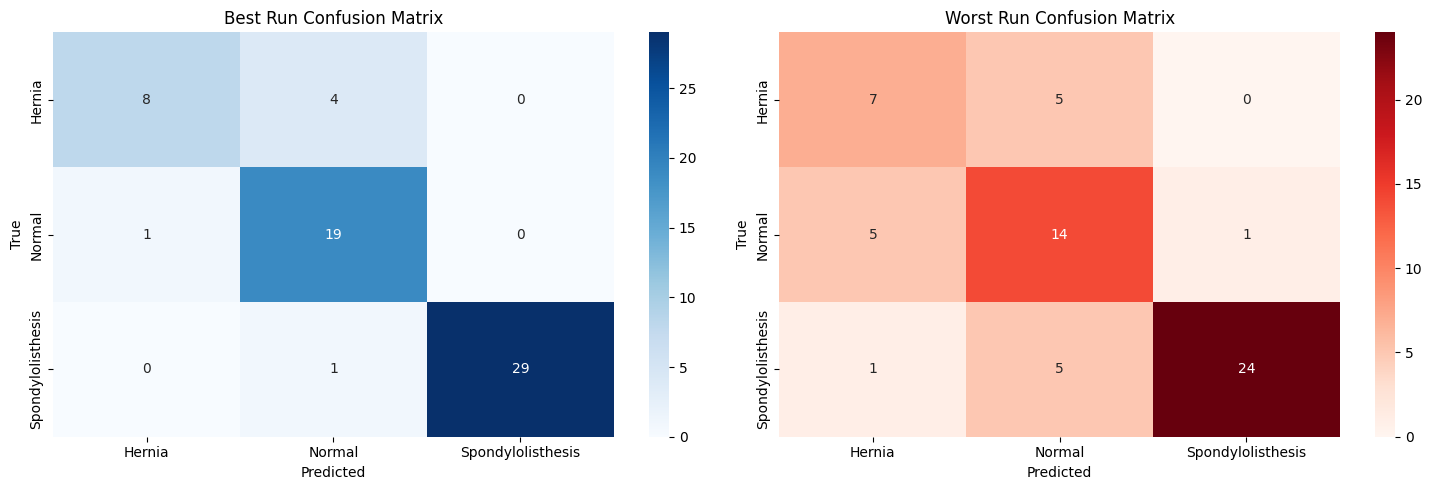

Classification Report for Best Run (#55):
                   precision    recall  f1-score   support

           Hernia       0.89      0.67      0.76        12
           Normal       0.79      0.95      0.86        20
Spondylolisthesis       1.00      0.97      0.98        30

         accuracy                           0.90        62
        macro avg       0.89      0.86      0.87        62
     weighted avg       0.91      0.90      0.90        62

--- KNN (m=2.00) ---
Best Run (#4) Accuracy: 0.9032
Worst Run (#32) Accuracy: 0.6935


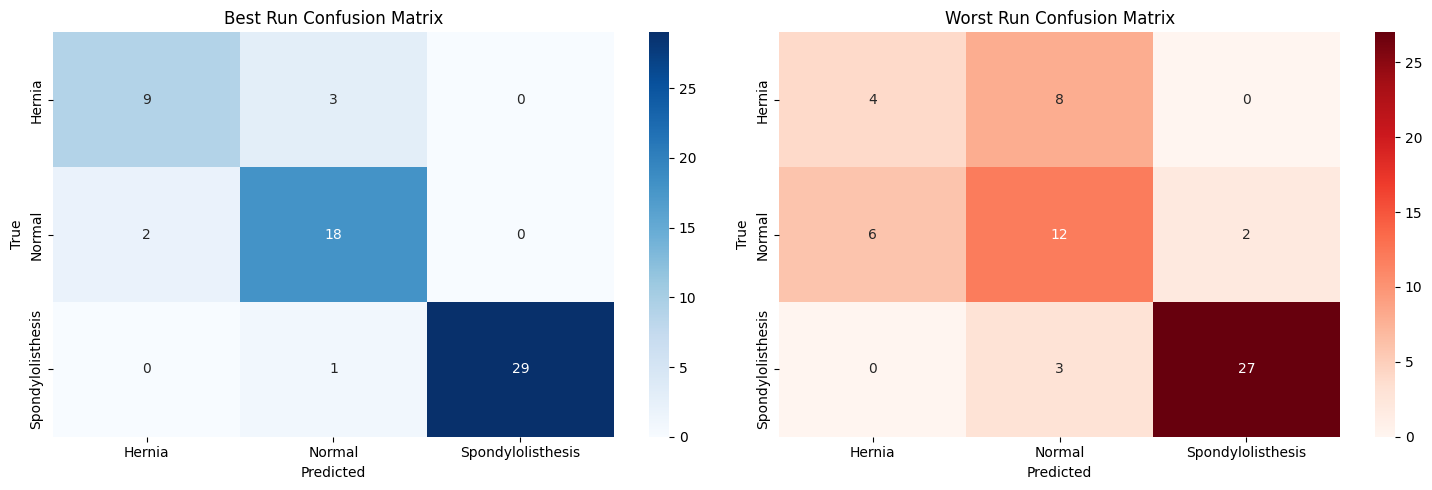

Classification Report for Best Run (#4):
                   precision    recall  f1-score   support

           Hernia       0.82      0.75      0.78        12
           Normal       0.82      0.90      0.86        20
Spondylolisthesis       1.00      0.97      0.98        30

         accuracy                           0.90        62
        macro avg       0.88      0.87      0.87        62
     weighted avg       0.91      0.90      0.90        62

--- KNN (m=2.50) ---
Best Run (#55) Accuracy: 0.9194
Worst Run (#32) Accuracy: 0.7258


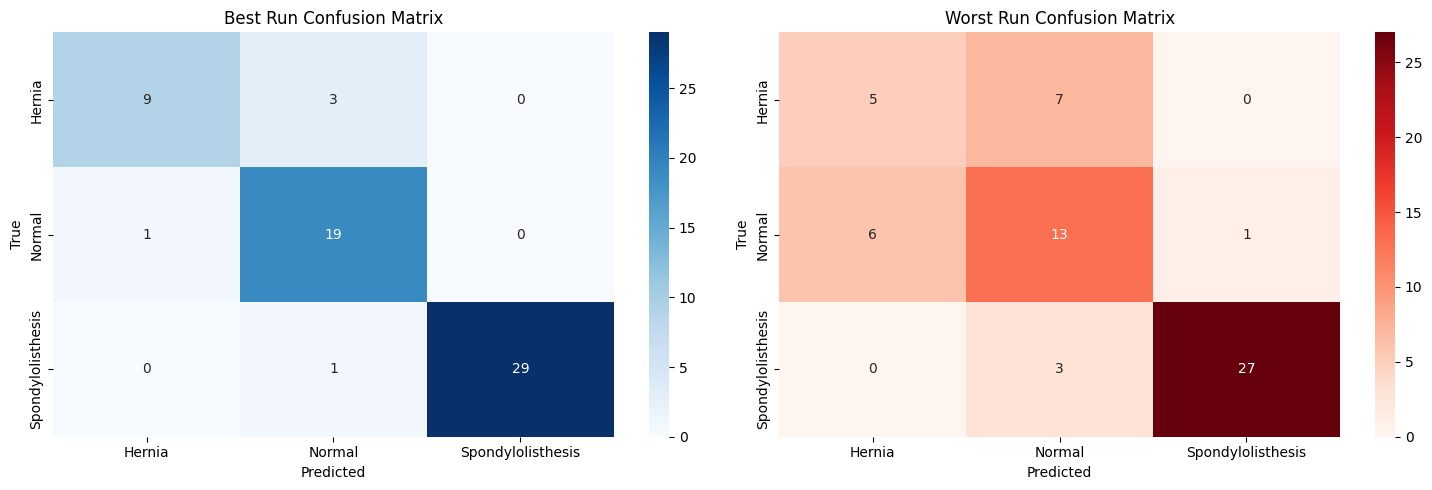

Classification Report for Best Run (#55):
                   precision    recall  f1-score   support

           Hernia       0.90      0.75      0.82        12
           Normal       0.83      0.95      0.88        20
Spondylolisthesis       1.00      0.97      0.98        30

         accuracy                           0.92        62
        macro avg       0.91      0.89      0.89        62
     weighted avg       0.92      0.92      0.92        62

--- MDC ---
Best Run (#23) Accuracy: 0.8871
Worst Run (#13) Accuracy: 0.6613


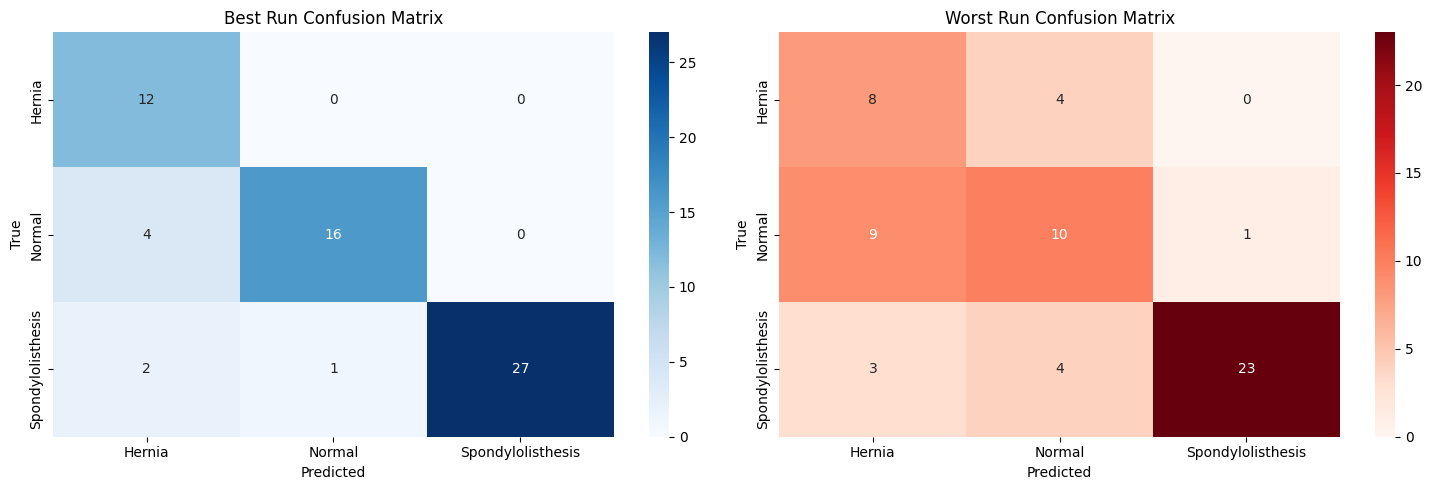

Classification Report for Best Run (#23):
                   precision    recall  f1-score   support

           Hernia       0.67      1.00      0.80        12
           Normal       0.94      0.80      0.86        20
Spondylolisthesis       1.00      0.90      0.95        30

         accuracy                           0.89        62
        macro avg       0.87      0.90      0.87        62
     weighted avg       0.92      0.89      0.89        62

--- MDC Robusto ---
Best Run (#28) Accuracy: 0.8710
Worst Run (#13) Accuracy: 0.6774


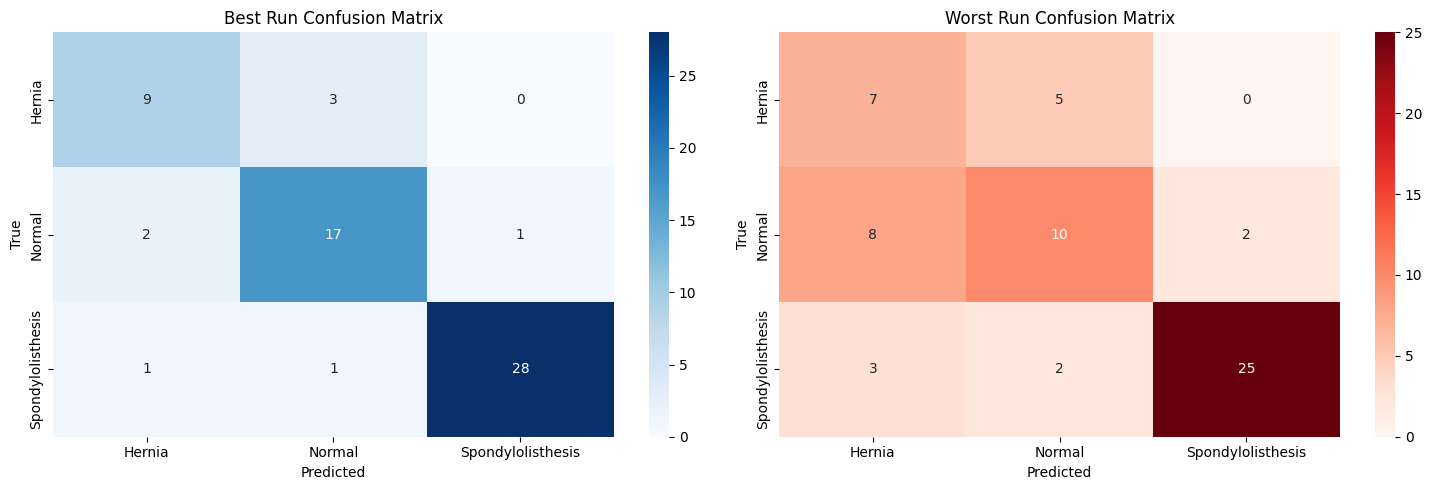

Classification Report for Best Run (#28):
                   precision    recall  f1-score   support

           Hernia       0.75      0.75      0.75        12
           Normal       0.81      0.85      0.83        20
Spondylolisthesis       0.97      0.93      0.95        30

         accuracy                           0.87        62
        macro avg       0.84      0.84      0.84        62
     weighted avg       0.87      0.87      0.87        62

--- MAXCO ---
Best Run (#79) Accuracy: 0.8871
Worst Run (#67) Accuracy: 0.5645


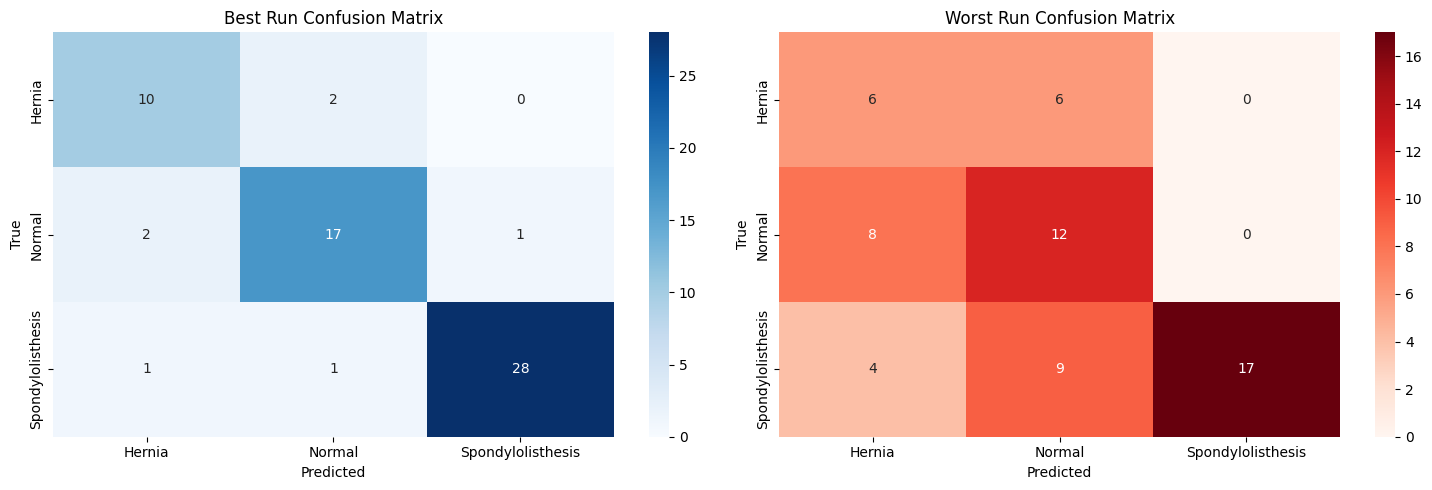

Classification Report for Best Run (#79):
                   precision    recall  f1-score   support

           Hernia       0.77      0.83      0.80        12
           Normal       0.85      0.85      0.85        20
Spondylolisthesis       0.97      0.93      0.95        30

         accuracy                           0.89        62
        macro avg       0.86      0.87      0.87        62
     weighted avg       0.89      0.89      0.89        62



In [11]:
test_splits = [0.8, 0.7, 0.5, 0.3, 0.2] # Corresponde a 20/80, 30/70, 50/50, 70/30, 80/20 train/test
all_split_results = {}

for split in test_splits:
    train_ratio = int((1-split)*100)
    test_ratio = int(split*100)
    print(f'==================================================================')
    print(f'   Running Experiments for Train/Test Split: {train_ratio}/{test_ratio}   ')
    print(f'==================================================================')
    
    results, le = run_experiments(X, y_raw, test_size=split, n_runs=100)
    analyze_results(results, le)
    all_split_results[f'{train_ratio}/{test_ratio}'] = results

### 5. OBS 3: Avaliação do Efeito da Separação Treino-Teste

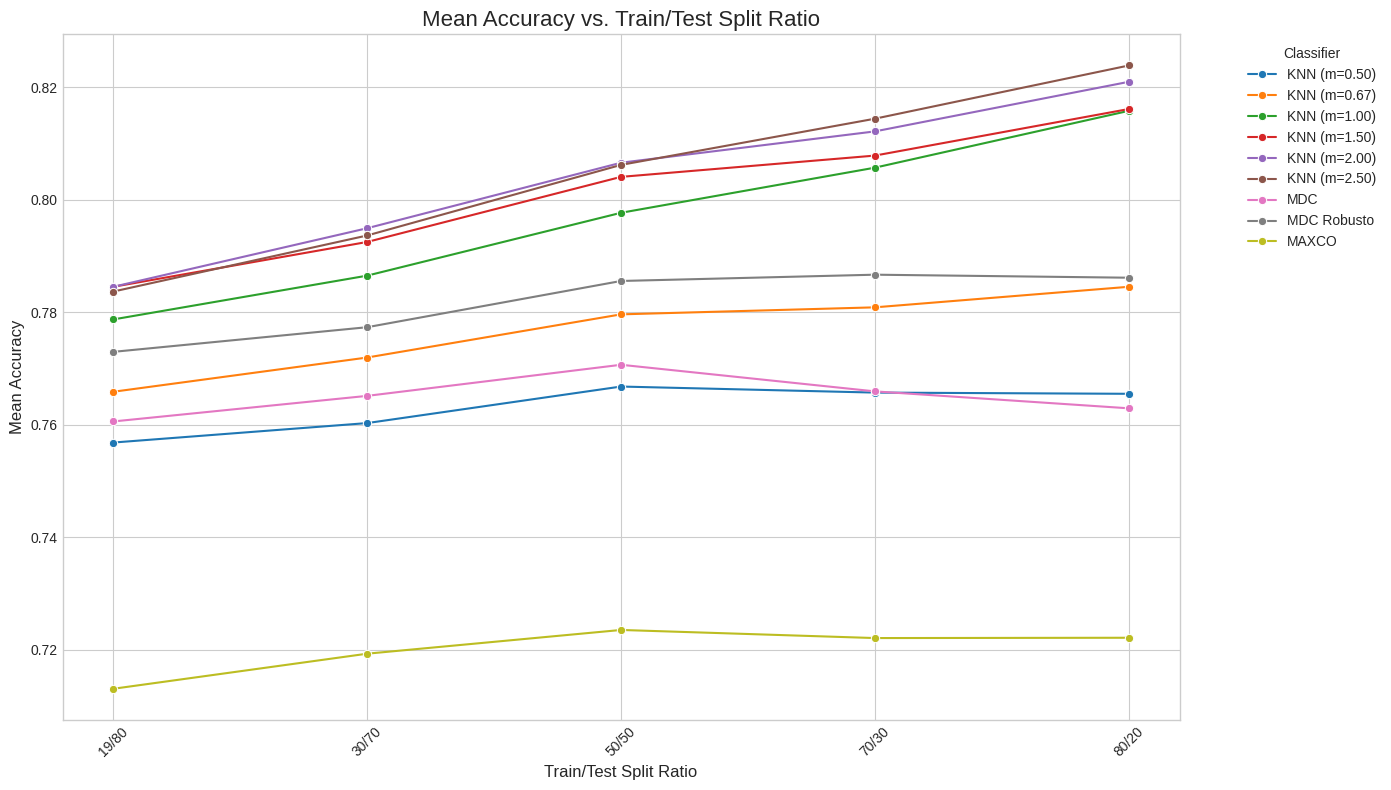

In [12]:
split_analysis_data = []
for split_ratio, results in all_split_results.items():
    for name, runs in results.items():
        mean_accuracy = np.mean([r['accuracy'] for r in runs])
        split_analysis_data.append({'Split': split_ratio, 'Classifier': name, 'Mean Accuracy': mean_accuracy})

split_df = pd.DataFrame(split_analysis_data)

plt.style.use('seaborn-v0_8-whitegrid')
fig, ax = plt.subplots(figsize=(14, 8))
sns.lineplot(data=split_df, x='Split', y='Mean Accuracy', hue='Classifier', marker='o', ax=ax)
ax.set_title('Mean Accuracy vs. Train/Test Split Ratio', fontsize=16)
ax.set_xlabel('Train/Test Split Ratio', fontsize=12)
ax.set_ylabel('Mean Accuracy', fontsize=12)
ax.legend(title='Classifier', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()